---
title: "FireIgnition: Lightning and New Fires with DEFAIR and Machine Learning"
subtitle: "A Destination Earth / DEFAIR use case: from lightning, fuel, rain and fire products to an AI ready cube and a model of lightning ignition over the Iberian Peninsula"
author: "Author: Alejandro Fonseca (EUMETSAT/Starion)"
tags: [DEFAIR, HDA, MTG, LI LFL, FCI GII, LSA SAF, H SAF, CLC+, Machine Learning]
thumbnail: img/EUMETSAT-icon.png
license: MIT
copyright: "© 2026 EUMETSAT"
---

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/DEFAIR/DEDL_DEFAIR_FireIgnition_lightning_with_machine_learning.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

# Overview

## Purpose of this notebook

Every summer, some of the fires in the Iberian Peninsula are started by lightning. Two instruments on
the same Meteosat Third Generation satellite now see both sides of that story: the Lightning Imager
records every flash, and the Flexible Combined Imager detects the fires that appear afterwards. This
notebook brings them together with three more pieces of the picture: how dry the vegetation was, how
much rain fell with the storm, and how much water the air held before it. DEFAIR turns these six
products from four providers into one AI ready data cube, and the cube is then used to answer two
questions: is lightning followed by more new fires, and does dry weather make that effect stronger.

Three of the six products have no reader in DEFAIR. The first part of the notebook shows how to write
one, register it and use it exactly like an official reader. After that, every source goes through
the same DEFAIR steps: read from S3, crop, reproject and align onto one grid.

## Scientific background

In the Mediterranean Basin, lightning causes about 15% of forest fires ([Soler et al., 2021](https://doi.org/10.1071/WF21076)). Lightning fires often start in remote areas, where they may spread before being detected and suppressed, and they can contribute to some of the largest summer fires. Dry thunderstorms, which produce lightning with little rainfall, are considered an important cause of these fires ([Pérez-Invernón et al., 2021](https://doi.org/10.5194/acp-21-17529-2021)). In Catalonia, roughly one in 1,000 cloud-to-ground flashes results in a flaming wildfire ([Soler et al., 2021](https://doi.org/10.1071/WF21076)). Therefore, the key question is not whether lightning can ignite vegetation, but **under which conditions a lightning strike leads to ignition**. 

This analysis builds on previous studies of lightning ignition probability in the Iberian Peninsula. [Vecín-Arias et al. (2016)](https://doi.org/10.1016/j.agrformet.2016.05.003) combined lightning, vegetation, topography, and weather data with logistic regression and random forests over central Spain. [Rodrigues et al. (2023)](https://doi.org/10.1071/WF22123) used more than 17 million lightning strikes to train a machine-learning model that predicts the daily probability of lightning ignition across the peninsula using fuel, vegetation, and lightning characteristics. [Pineda and Rigo (2017)](https://doi.org/10.1016/j.agrformet.2017.03.016) examined the role of rainfall during thunderstorms. The delay between the lightning strike and fire detection, known as the **holdover time**, is usually short. In the Swiss Alps, most fires were detected within 24 hours of the igniting lightning strike ([Moris et al., 2020](https://doi.org/10.1016/j.agrformet.2020.107990)). [Moris et al. (2023)](https://doi.org/10.5194/essd-15-1151-2023) provide a global overview of holdover times.

This use case applies the previous approach using a new observing system. The MTG Lightning Imager is the first geostationary optical lightning detector covering Europe ([Enno et al., 2026](https://doi.org/10.5194/egusphere-2026-3386)). It observes total lightning day and night across the entire Iberian Peninsula and measures the duration and extent of each flash, which are tested here as possible predictors of ignition.

The Flexible Combined Imager on the same satellite detects fires every ten minutes, allowing lightning and fires to be observed from the same platform and on the same time scale. Because fires are detected from space, the fire data are consistent across national borders and do not depend on national records of fire causes. Satellite products also provide information on atmospheric conditions before the storm and rainfall during the storm, which are important for the dry thunderstorms associated with large fires ([Pineda and Rigo, 2017](https://doi.org/10.1016/j.agrformet.2017.03.016); [Pérez-Invernón et al., 2021](https://doi.org/10.5194/acp-21-17529-2021)).

All inputs are available operationally. DEFAIR combines them into a single data cube, allowing the same analysis to be repeated for each new fire season as data become available. All data sources are satellite products derived and distributed through EUMETSAT and its Satellite Application Facilities.

This study covers the 37 convective episodes between 14 July and 9 September 2026 over the Iberian
Peninsula on wildland landcover (woody needle leaved trees, broadleaved deciduous trees, broadleaved evergreen trees, shrubs and permanent herbaceous).

## Research questions

**RQ1.** Do wildland cells hit by lightning have a higher probability of a new fire in the 48 hours
after the first flash than the same cells without lightning under similar rain?

**RQ2.** Does that excess risk depend on how dry the fuel is and how much water the air held before
the storm?

## Hypotheses

RQ1 is answered with the relative risk (RR): the probability of a new fire in cells with lightning
divided by the probability in cells without it.

$$
RR = \frac{P(\text{fire} \mid \text{lightning})}
{P(\text{fire} \mid \text{no lightning})}
$$

- **H0 (null hypothesis):** RR = 1. Cells with and without lightning have the same probability of a new fire.
$$
P(\text{fire} \mid \text{lightning}) = P(\text{fire} \mid \text{no lightning})
$$
- **H1 (alternative hypothesis):** RR > 1. A new fire is more likely where lightning struck.

H0 is rejected when the whole 95 % interval of the RR lies above 1. An interval that includes 1 is a
valid result, not a failure.

RQ2 compares that relative risk between dry and wet conditions. If dry thunderstorms are the ones that
start fires, the relative risk should be larger where the fuel is drier and where the air held less
water: RR(dry) > RR(wet). RQ2 is exploratory: it measures the size and direction of the
effect without a formal test.

## Data Sources

| Product | Instrument / platform | Source | Format | Variables (units) | Role in the analysis |
|---|---|---|---|---|---|
| [**LI LFL**](https://user.eumetsat.int/resources/user-guides/mtg-li-level-2-data-guide) (Lightning Flashes, Level 2) | Lightning Imager, MTG-I1 | EUMETSAT, DestinE HDA | NetCDF4, one file per 10 minute slot, a list of flashes | `flash_time` (UTC), `latitude`, `longitude` (°), `flash_duration` (ms), `flash_footprint` (number of LI pixels), `number_of_events` (count) | Exposure (was the cell hit?) and storm descriptors |
| [**FCI GII**](https://user.eumetsat.int/resources/user-guides/mtg-fci-l2-gii-data-guide) (Global Instability Indices, Level 2) | Flexible Combined Imager, MTG-I1 | EUMETSAT, DestinE HDA | NetCDF4, one file per 10 minute slot, full disc grid of about 6 km, clear sky only | `k_index` (K), `lifted_index` (K), `prec_water_total` (kg m⁻², equivalent to mm) | Atmosphere before the storm |
| [**LSA-509 FRP-Pixel**](https://lsa-saf.eumetsat.int/en/data/products/fire-products/) | Flexible Combined Imager, MTG-I1 | LSA SAF (IPMA) data service | NetCDF4, one file per 10 minute slot with a fire list and a 1 km quality image, archived as daily Iberian crops | `ACQTIME` (UTC), `LATITUDE_PARALLAX`, `LONGITUDE_PARALLAX` (°), `ABS_LINE`, `ABS_SAMP` (FCI pixel), `FRP` (MW), `qualityflag` (class) | Label (new fire) and observability |
| [**LSA FRM**](https://lsa-saf.eumetsat.int/en/data/products/fire-products/) (Fire Risk Map, 24 h forecast) | SEVIRI, MSG | EUMETSAT, DestinE HDA | HDF5, one file per day, 3 km | `FWI`, `FFMC`, `DMC`, `DC` (dimensionless codes) | State of the fuel |
| [**H SAF H61B**](https://hsaf.meteoam.it/Products/Detail?prod=H61B) | SEVIRI, MSG | H SAF, official FTP | Gzipped NetCDF, one file per day, full disc at 3 km | `acc_rr` (mm) | Rain that fell with the lightning |
| [**CLC+ Backbone 2023**](https://library.land.copernicus.eu/products/CLCplus_Backbone_2023_PUM_v1.pdf) | Product derived from Sentinel-2 MSI time series | Copernicus Land Monitoring Service, WEkEO | GeoTIFF tiles, 10 m, EPSG:3035 | Eleven land cover classes  | Study area and fuel type |

The raw products were archived once in the project bucket by separate ingestion runs, untouched
except for two datasets: the LSA-509 full disc files were cut to a fixed Iberian window of
rows and columns without transforming any value, and CLC+ was aggregated to the class fractions of
each 10 km cell.

An **episode**, or storm day, is one calendar day of the 2026 season, from 00:00 to 24:00 UTC, with significant
lightning over the study area. The Lightning Imager delivers one flash file every ten minutes, 144
per day, so the season was screened cheaply: for each day only three of those files were read, at
13:00, 17:00 and 21:00 UTC, and the day was kept when they held at least 100 flashes over Iberia.
The screen detects active days but does not count their flashes, and a short storm that fell
entirely outside the three sampled slots can be missed. It found 37 episodes between 14 July and 9
September.

## Assumptions and simplifications

**One sample is one cell on one storm day.** The study area is divided into 10 km cells, and each cell
is followed on each of the 37 storm days. A cell is *exposed* when the Lightning Imager saw at least one
flash in it that day. The instrument sees all lightning and cannot tell the flashes that reach the
ground from those that stay inside the cloud.

**Flashes are moved to where they happened.** The Lightning Imager places each flash where the line of
sight of the satellite meets the ground. A flash high up in a cloud therefore appears about 10 km too
far north over Iberia, the size of one cell
([Bližňák and Sokol, 2026](https://doi.org/10.1016/j.jag.2026.105205)). Each flash is moved back along
the line of sight to a height of 10 km. Real flash heights vary, so a small shift remains.

**Each cell has its own 48 hour window.** In a cell with lightning, the window starts at its first
flash. In a cell without lightning, it starts at the storm time of the day: the moment lightning
typically reached the study area. A fire seen
inside the window counts as new. A fire seen before the window cannot have been lit by that storm.

**A new fire must really be new.** If the cell or any of its eight neighbours already had a fire in the
48 hours before the window, the cell is left out of that day. A later detection there is probably the
same fire, or one spreading in from next door.

**A cell only counts if the satellite could see it.** Clouds hide fires. A cell is kept only if fire
detection was possible in at least a quarter of its pixels and images during the window. Without this
rule, cloudy cells, which are usually the ones with lightning, would too often be counted as "no fire".

**Each fire is counted once.** Storm days often follow each other, so one fire can fall inside the
windows of two days. It is given to the day whose window started last before the fire appeared: the most
recent storm. This rule does not look at lightning, and it can only go wrong in one direction: a fire lit
by lightning but seen only after the next storm day has started goes to that next day, and if the cell had
no lightning then, the fire counts against lightning. The rule can therefore underestimate the effect,
but not inflate it.

**Industrial heat sources are removed.** The fire product cannot tell a wildfire from a gas flare. A
1 km pixel that lights up in three periods separated by at least a week, or on twenty or more days, is
treated as a fixed source and removed together with its eight neighbours. A wildfire burns its fuel
and does not keep coming back. Both thresholds are reasoned choices, not calibrated values.

**Cells are compared with themselves.** A cell with lightning is compared with the same cell on other
days, without lightning and with similar rain. This keeps its terrain, vegetation and human activity
fixed, and takes out the effect of the rain that comes with the storm. The rain classes are no rain,
up to 1 mm, 1 to 5 mm, 5 to 15 mm and more than 15 mm.

**The air is read before the storm.** The instability indices only exist under clear sky, so they are
read between three hours and one hour before the storm time of the day. For a cell that the
storm reaches late in the day, they describe the air of the morning.

**Association, not causation.** There is no record of what lit each fire. The study measures how often
new fires follow lightning, not which flash lit which fire.

## How the notebook is organised

First come the readers, then the study grid, the fire label and the features of each storm day, which
are put together into the cube and published. The analysis then reads the cube back, as any user
would. RQ1 is answered with a relative risk that compares each cell with itself, followed by a look at
when the fires appear and two checks of the design. RQ2 splits the same relative risk into dry and wet
conditions and adds two classifiers. Every model is tested on storm days
it never saw during training. Building all 37 days takes about half an hour, so by default
(`BUILD_CUBE = False`) the notebook builds one day live, to show every step, and then reads the
published cube.

## Prerequisites

Reading is anonymous: the project bucket is public, so the notebook runs without credentials. The
three new readers live in the `readers` folder next to this notebook, as a small Python package. It is
installed once, together with scikit-learn and XGBoost, and then **the kernel must be restarted** so
that DEFAIR can find the readers. Rebuilding and republishing the cube (`BUILD_CUBE = True`) is the only
step that writes, and it needs the DataLake S3 keys. **Anyone can rebuild it into their own store by
changing `BUCKET` and `S3_ENDPOINT` in the configuration.**

In [ ]:
%pip install -e readers matplotlib scikit-learn xgboost

In [2]:
from defair.logging import setup_logging
from defair.plugin_manager import list_readers, load_reader, load_source
from defair_data.core import Dataset
from defair_data.data_reader_plugin import DataReaderPlugin
from defair_ops.transformations.alignment import AlignmentPlugin
from defair_ops.transformations.reprojection import ReferenceGrid

import os
import time
from dotenv import load_dotenv
from pathlib import Path
from getpass import getpass

import boto3
from botocore import UNSIGNED
from botocore.client import Config
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from affine import Affine
from pyproj import CRS, Geod, Transformer
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part")   # harmless Zarr 3 notice

setup_logging(log_level="ERROR")   # keeps the output readable; use "INFO" to inspect the pipeline

In [ ]:
# Use case configuration

# Convective episodes of the 2026 season: days with at least 100 flashes over Iberia in the season scan.
# The scan found 37
EPISODES = ["2026-07-14", "2026-07-15", "2026-07-16", "2026-07-17", "2026-07-19",
            "2026-07-20", "2026-07-24", "2026-07-25", "2026-07-30", "2026-08-01", "2026-08-03",
            "2026-08-04", "2026-08-06", "2026-08-07", "2026-08-08", "2026-08-09", "2026-08-10",
            "2026-08-11", "2026-08-12", "2026-08-13", "2026-08-14", "2026-08-15", "2026-08-16",
            "2026-08-17", "2026-08-19", "2026-08-20", "2026-08-22", "2026-08-23", "2026-08-24",
            "2026-08-26", "2026-08-27", "2026-08-31", "2026-09-01", "2026-09-02", "2026-09-05",
            "2026-09-06", "2026-09-09"]
DEMO_EPISODE = "2026-08-10"

# Study area and grid: EPSG:3035 at 10 km
BBOX = [-10.0, 36.0, 4.0, 44.0]                       # lon_min, lat_min, lon_max, lat_max
MARGIN = 2.0                                          # degrees kept around the bbox when cropping
X0, Y1, CELL, NX, NY = 2_600_000, 2_500_000, 10_000, 130, 100
FACTOR = 10                                           # gridded sources are aligned at 1 km, then averaged 10 x 10
GRID_1KM = ReferenceGrid(crs="EPSG:3035", transform=Affine(CELL / FACTOR, 0.0, X0, 0.0, -CELL / FACTOR, Y1),
                         width=NX * FACTOR, height=NY * FACTOR)
SPATIAL_METHOD = "nearest"                            # the area average over each 10 km cell is taken after alignment

# Lightning geolocation: every flash is moved from the ground to a cloud at a fixed height
SAT_LON, SAT_HEIGHT = 0.0, 35_786_400.0               # MTG-I1 sub satellite longitude [deg] and height [m]
PARALLAX_HEIGHT = 10_000.0                            # assumed height of the lightning [m]

# Decisions of the study design (see Assumptions)
WILDLAND_MIN_FRACTION = 0.5                           # at least 50 of the 100 km2 are natural vegetation
LABEL_HOURS, PRIOR_HOURS = 48, 48                     # label: 48 h from the first flash in the cell (or the storm time); prior: 48 h before
SLOTS_PER_WINDOW = LABEL_HOURS * 6                    # 10 minute slots in a label window
MIN_OBS_FRACTION = 0.25                               # a cell enters the sample when visible in a quarter of its window
GII_FROM, GII_TO = pd.Timedelta(hours=3), pd.Timedelta(hours=1)
PERSISTENT_GAP_DAYS, PERSISTENT_MIN_EPISODES = 7, 3   # a pixel active in 3 periods separated by 7 days is a fixed source
DAILY_SOURCE_MIN_DAYS = 20                            # a pixel active on 20 days of the season is a fixed source too
OBSERVED_CLASSES = [0, 1, 2]                          # quality flags where fire detection was possible

# Analysis
RAIN_BINS = [-np.inf, 0, 1, 5, 15, np.inf]            # rain classes, in mm, used as strata together with the cell
RAIN_LABELS = ["0", "0-1", "1-5", "5-15", ">15"]
STRATA = ["cell", "rain_class"]                       # a cell is compared with itself under similar rain
DOSE_BINS, DOSE_LABELS = [0, 5, 20, 100, np.inf], ["1-5", "6-20", "21-100", ">100"]   # flashes per cell
FEATURES_RQ2 = ["h61_precip", "frm_ffmc", "frm_dmc", "frm_dc", "lfl_flash_count", "lfl_duration_mean",
                "lc_trees", "season_day", "y", "cell_base_rate"]
N_BOOT_RR, N_BOOT = 1000, 200                         # bootstrap resamples of episodes: main relative risk; the rest
N_PERM = 200                                          # shuffles of the negative control
SEED = 0

# Local workspace and cube location
ROOT = Path.cwd()                                     # the folder of this notebook
CUBE_DIR = ROOT / "data" / "fireignition"
CUBE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_CUBE = CUBE_DIR / "fireignition_cube.zarr"
CUBE_KEY = "cubes/fireignition_cube.zarr/"
BUILD_CUBE = False                                    # True rebuilds the 37 episodes and republishes the cube (about 30 min)

In [4]:
# S3 access

#=====================================================================================
# S3 object store: edit these three lines to point at a different store!!

S3_ENDPOINT = "https://s3.central.data.destination-earth.eu"
BUCKET      = "defair-use-case"
PREFIX      = ""   # source prefixes and cubes/ live at the bucket root
#=====================================================================================

# The bucket is public for reading, so every read in this notebook is anonymous
S3_SOURCE_KWARGS = {"anon": True, "endpoint_url": S3_ENDPOINT}
READ = {"source": "s3", "source_kwargs": S3_SOURCE_KWARGS}
STORAGE_OPTIONS = {"anon": True, "client_kwargs": {"endpoint_url": S3_ENDPOINT}}

s3 = boto3.client("s3", endpoint_url=S3_ENDPOINT, config=Config(signature_version=UNSIGNED))

s3_write = None
if BUILD_CUBE:                                        # writing is the only step that needs keys
    load_dotenv(ROOT / ".env")
    s3_write = boto3.client("s3", endpoint_url=S3_ENDPOINT,
                            aws_access_key_id=os.environ.get("S3_ACCESS_KEY") or getpass("S3 access key: "),
                            aws_secret_access_key=os.environ.get("S3_SECRET_KEY") or getpass("S3 secret key: "))

In [5]:
# Object listing and the location of each raw product in the bucket

paginator = s3.get_paginator("list_objects_v2")   # pagination is mandatory on DestinE (buckets over 1000 objects)
def s3_keys(prefix):
    """All object keys under a prefix, paginated."""
    return sorted(o["Key"] for p in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX + prefix)
                  for o in p.get("Contents", []))

def frm_path(day):
    d = pd.Timestamp(day)
    return f"s3://{BUCKET}/{PREFIX}frm-orig/{d:%Y-%m-%d}/S-LSA_-HDF5_LSASAF_MSG_FRM-F024_Euro_{d:%Y%m%d}1200"

def h61_path(day):
    sealed = pd.Timestamp(day) + pd.Timedelta(days=1)      # the accumulation of day D is sealed at D+1 00:00
    return f"s3://{BUCKET}/{PREFIX}precip-orig/h61_{sealed:%Y%m%d}_0000_24_fdk.nc.gz"

def lsa_path(day):
    return f"s3://{BUCKET}/{PREFIX}lsa509-iberia/LSA509_iberia_{pd.Timestamp(day):%Y%m%d}.nc"

# DEFAIR Reader plugins

## What is a reader?

DEFAIR does not open product files directly. Instead, it uses a **reader**, a small plugin that understands the structure of a specific file format and converts its contents into an `xarray.Dataset`.

A reader is a Python class that inherits from `DataReaderPlugin` and implements a single method, `read()`. This is the only requirement. The base class provides the rest of the functionality, including `self.open_file(path, source, source_kwargs)`. This method opens the requested file regardless of where it is stored, whether on a local disk, in an S3 bucket, or in the HDA.

Because `open_file()` handles the storage layer, the reader does not need to manage credentials, storage protocols, or file downloads. The same reader code can therefore be used to read a local file or an object stored in a bucket.

## What does a reader enable?

Once a product has a reader, it can be handled by DEFAIR like any other supported product. This includes:

- streaming data directly from S3,
- reading multiple files,
- cropping,
- reprojection, and
- spatial alignment.

An alternative would be to convert the product outside DEFAIR and import the resulting arrays. However, this approach would bypass these capabilities. DEFAIR ships with **built-in readers** for the METOP, MTG, Sentinel-3, MSG native and ERA5 families, among others. For any other source, you can write your **own reader** and register it as a plugin. Once registered,
the framework treats it exactly like a built-in one.

Implementing a reader requires only a small amount of code, after which the product can be processed by DEFAIR in the same way as products with built-in readers.

## Which sources in this case need a reader?

In this case, two of the six sources are already supported by built-in readers, while three require custom readers:

| Source | Reader |
|---|---|
| MTG Lightning Imager flashes | `mtg_li_lfl`, built in |
| MTG instability indices | `mtg_l2_gii`, built in |
| LSA SAF Fire Risk Map | None, implemented in this notebook |
| LSA SAF FRP-Pixel | None, implemented in this notebook |
| H SAF precipitation | None, implemented in this notebook |
| CLC+ land cover | Not needed, as it is already provided in aggregated form |

## Building a reader step by step: the Fire Risk Map

This section builds the reader of the LSA SAF Fire Risk Map from scratch, one step at a time. Each
step adds one piece to the same reader and is checked on the same file, the Fire Risk Map of the demo
episode. The file holds five variables: the four codes of the Canadian system (`FWI`, `FFMC`, `DMC`,
`DC`) and the danger class (`Risk`). The Fire Weather Index, `FWI`, is used to follow the changes from
one step to the next. At the end the pieces are put together in one class, which is exactly the
`lsa_frm` reader of the `readers` package, which is then registered and called by its name, like any
built-in reader.

### Step 1: open the file

The first version of the reader does only one thing: open the file and hand its contents to xarray.
The reader is a class, `FRMReader`, that inherits from `DataReaderPlugin`, the base class of every
DEFAIR reader. It needs just one method, `read()`, which receives the path of the file and returns
its contents.

Inside `read()`, two lines do the work. The first, `self.open_file`, is provided by DEFAIR: it finds
the file wherever it is stored, here in the project bucket, so the reader never deals with
credentials or downloads. The second opens that file with xarray, with two options that matter for
this format. `phony_dims="sort"` gives names to the dimensions, because the HDF5 file does not
include any. `mask_and_scale=False` keeps the values exactly as they are stored, so that we can see
the raw content before transforming it.

Finally, `load_reader` turns the class into a working reader without installing or registering
anything, which is the quickest way to test a reader while it is being written. The last line shows
one of the variables it returns, the Fire Weather Index.

In [31]:
class FRMReader(DataReaderPlugin):
    """Fire Risk Map reader, step 1: open the file through DEFAIR's source layer."""

    def read(self, path, source=None, source_kwargs=None):
        f = self.open_file(path, source, source_kwargs)
        return xr.open_dataset(f, engine="h5netcdf", phony_dims="sort", mask_and_scale=False)

reader = load_reader("frm_step1", plugin_class=FRMReader, fresh=True)
raw = reader.read(frm_path(DEMO_EPISODE), **READ)
raw["FWI"]

<xarray.DataArray 'FWI' (phony_dim_0: 651, phony_dim_1: 1701)> Size: 2MB
[1107351 values with dtype=int16]
Dimensions without coordinates: phony_dim_0, phony_dim_1
Attributes:
    CAL_OFFSET:      999.0
    CAL_SLOPE:       999.0
    MISSING_VALUE:   -8000
    NB_BYTES:        2
    N_COLS:          1701
    N_LINES:         651
    OFFSET:          0.0
    PRODUCT:         FWI
    PRODUCT_ID:      999
    SCALING_FACTOR:  100.0
    UNITS:           Dimensionless

The file is read, but it is not usable yet. The Fire Weather Index is stored as 16 bit integers, so a
value of `2345` means 23.45, and `-8000` marks pixels without data. The dimensions have no
names (`phony_dim_0`, `phony_dim_1`) and no coordinates, so nothing says where on Earth each pixel
is, and there is no time. A model fed with this would learn from numbers a hundred times too large
and from a sea filled with -8000, and the field could not be combined with any other source. The next
three steps fix each of these problems.

### Step 2: physical values

The LSA SAF stores each variable as an integer `X` with attributes of its own, and defines the
physical value as `X / SCALING_FACTOR + OFFSET`, with `MISSING_VALUE` for pixels without data (LSA SAF, *Product Output Format*, SAF/LAND/IPMA/POF/1.2, available in the
[LSA SAF documentation repository](https://nextcloud.lsasvcs.ipma.pt/s/CjtrxjMcYBz5wT7?dir=/PUM-Product_User_Manual)). Those names are not part of the CF
conventions, the metadata standard that xarray, DEFAIR and most EO tools understand, so no tool
applies them. The reader does not do the arithmetic itself: it translates the attributes into their
CF equivalents, `scale_factor = 1 / SCALING_FACTOR` (CF multiplies where the LSA SAF divides),
`add_offset` and `_FillValue`, and lets the standard decoder, `xr.decode_cf`, produce the physical
values. This is the same conversion the LSA SAF applies when it publishes its own NetCDF files. The five variables are loaded, the dimensions get their usual names, `y` for
rows and `x` for columns, and each variable is also told which grid mapping describes its
projection, `geostationary`, which is added in step 4.

In [7]:
VARIABLES = ["FWI", "FFMC", "DMC", "DC", "Risk"]
ds = raw[VARIABLES].load()

ds = ds.rename({"phony_dim_0": "y", "phony_dim_1": "x"})
for v in VARIABLES:
    a = ds[v].attrs
    ds[v].attrs = {
        "scale_factor": np.float32(1 / a["SCALING_FACTOR"]),
        "add_offset": np.float32(a["OFFSET"]),
        "_FillValue": np.int16(a["MISSING_VALUE"]),
        "long_name": a["PRODUCT"],
        "units": "1",
        "grid_mapping": "geostationary",
    }
ds = xr.decode_cf(ds)

fwi = ds["FWI"]
print(f"FWI {fwi.dtype}: from {float(fwi.min()):.2f} to {float(fwi.max()):.2f}, "
      f"{float(fwi.isnull().mean()):.1%} of the pixels without data")

ds

FWI float32: from 0.00 to 149.07, 61.3% of the pixels without data


<xarray.Dataset> Size: 22MB
Dimensions:  (y: 651, x: 1701)
Dimensions without coordinates: y, x
Data variables:
    FWI      (y, x) float32 4MB ...
    FFMC     (y, x) float32 4MB ...
    DMC      (y, x) float32 4MB ...
    DC       (y, x) float32 4MB ...
    Risk     (y, x) float32 4MB ...
Attributes: (12/52)
    ARCHIVE_FACILITY:                IM-PT
    ASSOCIATED_QUALITY_INFORMATION:  -
    CENTRE:                          IM-PT
    CFAC:                            13642337
    CLOUD_COVERAGE:                  -
    COFF:                            308
    ...                              ...
    STATISTIC_TYPE:                  -
    SUB_SATELLITE_POINT_END_LAT:     0.0
    SUB_SATELLITE_POINT_END_LON:     0.0
    SUB_SATELLITE_POINT_START_LAT:   0.0
    SUB_SATELLITE_POINT_START_LON:   0.0
    TIME_RANGE:                      Daily,Fc-024

The values are now physical: decimal numbers on the scale of the index, and the pixels without data,
the sea and the space around the Earth, are `NaN` instead of -8000.

### Step 3: georeference

After step 2 the values are right, but the pixels still have no position on Earth. Three ideas give
them one.

The Fire Risk Map is not the full disc but a window over Europe and North Africa.
The file's metadata says where that window sits, following the CGMS (Coordination Group for Meteorological Satellites) navigation standard of EUMETSAT: its
attributes `COFF` and `LOFF` are the column and the row of the window where the centre of the disc
falls. Since the centre of the full disc is always the same pixel, the row and
column where the window starts follow by subtraction. Nothing is measured or assumed: the two numbers
come from the header of the file.

**The coordinates.** With the start of the window and the size of a pixel, the position of the centre
of every column, `x`, and every row, `y`, is a sum. The projection is written in `GEOS_ATTRS` in CF
form, so that any tool can compute the latitude and longitude of any pixel from `x` and `y`.

The check below draws the Fire Weather Index on its new coordinates and outlines the study area,
converted from longitude and latitude to the same projection. The outline must frame the Iberian
Peninsula.

COFF = 308, LOFF = 1808: the window starts at column 1549 and row 49 of the full disc


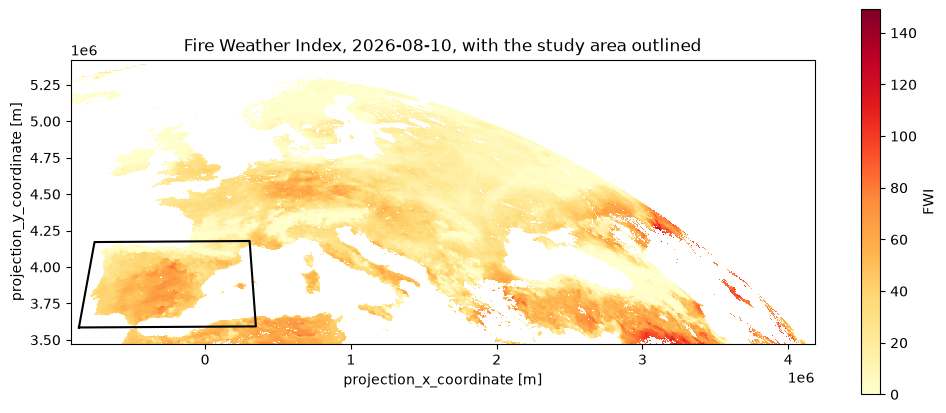

In [8]:
# The disc: the standard SEVIRI full disc at 3 km (area msg_seviri_fes_3km)
DISK_SIZE = 3712
DISK_EXTENT = (-5570248.686685662, -5567248.28340708, 5567248.28340708, 5570248.686685662)
GEOS_ATTRS = {
    "grid_mapping_name": "geostationary",
    "longitude_of_projection_origin": 0.0,
    "latitude_of_projection_origin": 0.0,
    "perspective_point_height": 35785831.0,
    "sweep_angle_axis": "y",
    "semi_major_axis": 6378169.0,
    "semi_minor_axis": 6356583.8,
    "false_easting": 0.0,
    "false_northing": 0.0,
}

# The window: where the Fire Risk Map starts within the disc, from the CGMS attributes of the file
coff, loff = int(raw.attrs["COFF"]), int(raw.attrs["LOFF"])   # window column and row of the disc centre, counted from 1
centre = DISK_SIZE // 2                                        # the same disc centre in the full disc, counted from 0
col0, row0 = centre - (coff - 1), centre - (loff - 1)
print(f"COFF = {coff}, LOFF = {loff}: the window starts at column {col0} and row {row0} of the full disc")

# The coordinates: the centre of every column and row, in metres, in the view of the satellite
dx = (DISK_EXTENT[2] - DISK_EXTENT[0]) / DISK_SIZE
x = DISK_EXTENT[0] + (col0 + np.arange(ds.sizes["x"]) + 0.5) * dx
y = DISK_EXTENT[3] - (row0 + np.arange(ds.sizes["y"]) + 0.5) * dx
ds = ds.assign_coords(
    x=("x", x, {"standard_name": "projection_x_coordinate", "units": "m", "axis": "X"}),
    y=("y", y, {"standard_name": "projection_y_coordinate", "units": "m", "axis": "Y"}),
)

# Check: the study area, converted to the same projection, must frame the Iberian Peninsula
to_geos = Transformer.from_crs("EPSG:4326", CRS.from_cf(GEOS_ATTRS), always_xy=True)
bx, by = to_geos.transform([BBOX[0], BBOX[2], BBOX[2], BBOX[0], BBOX[0]],
                           [BBOX[1], BBOX[1], BBOX[3], BBOX[3], BBOX[1]])
fig, ax = plt.subplots(figsize=(12, 5))
ds["FWI"].plot(ax=ax, cmap="YlOrRd", cbar_kwargs={"label": "FWI"})
ax.plot(bx, by, color="black")
ax.set_aspect("equal")
ax.set_title(f"Fire Weather Index, {DEMO_EPISODE}, with the study area outlined")
plt.show()

### Step 4: time and metadata

After step 3 every pixel has a position on Earth, but the dataset still does not say when it was
observed. This step adds the date and completes the description of the dataset.

- **The date.** The file stores its date in the global attribute `IMAGE_ACQUISITION_TIME`. The reader
reads it and turns it into a `time` dimension with a single value. This is what later lets DEFAIR
stack the files of different days along time. In the notebook the date is called `acquired`, because
`time` is already the name of a Python module used further down.

- **The projection.** In step 2 every variable was told that its projection is described by a variable
called `geostationary`. That variable is created now, as a coordinate: it holds no data, only the
attributes of the projection defined in step 3. It has to be a coordinate because that is where the
reprojection tools used by DEFAIR look for the projection of each variable.

- **The description.** Finally, the global attributes record what the dataset is and where it comes
from.

In [9]:
acquired = pd.to_datetime(str(raw.attrs["IMAGE_ACQUISITION_TIME"]), format="%Y%m%d%H%M%S")
ds = ds.expand_dims(time=[acquired])
ds = ds.assign_coords(geostationary=xr.DataArray(np.int32(0), attrs=GEOS_ATTRS))
ds.attrs = {
    "Conventions": "CF-1.8",
    "source": "LSA SAF Fire Risk Map, MSG SEVIRI Euro window",
    "time_range": raw.attrs["TIME_RANGE"],
    "nominal_product_time": str(raw.attrs["NOMINAL_PRODUCT_TIME"]),
}
ds

<xarray.Dataset> Size: 22MB
Dimensions:        (time: 1, y: 651, x: 1701)
Coordinates:
  * time           (time) datetime64[us] 8B 2026-08-10T12:00:00
  * y              (y) float64 5kB 5.422e+06 5.419e+06 ... 3.474e+06 3.471e+06
  * x              (x) float64 14kB -9.211e+05 -9.181e+05 ... 4.177e+06 4.18e+06
    geostationary  int32 4B 0
Data variables:
    FWI            (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
    FFMC           (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
    DMC            (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
    DC             (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
    Risk           (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:           CF-1.8
    source:                LSA SAF Fire Risk Map, MSG SEVIRI Euro window
    time_range:            Daily,Fc-024
    nominal_product_time:  202608090801

Written one after the other inside a single `read()` method, these four steps are the complete
reader. It is stored as `LSAFRMReaderPlugin` in `readers/lsa_frm.py`, under the name `lsa_frm`, with
three small additions that let DEFAIR drive it on its own. The method `can_handle` recognises Fire
Risk Map files by the shape of their name, since they have no extension. The argument `variables`
lets the user load only the variables they need, and defaults to the five of step 2. The method
`_build_cdm` declares what kind of data the reader returns, a grid on a geostationary projection,
which tells DEFAIR that this source can be reprojected and resampled onto a target grid. A list of
points, such as the fire detections further down, cannot be treated that way, which is why the
notebook counts flashes and detections into the cells itself. The reader returns its arrays lazily,
so an archive larger than the memory of the machine can still be processed.

### Step 5: registering the reader

Up to here the reader has been used through `load_reader`, which builds it straight from a class and
is enough to test it on one file. The call used everywhere else in the notebook,
`Dataset.from_source`, is the one that reads a list of files or a whole archive from S3, and it
receives the reader by **name**, not by class. DEFAIR finds the class behind a name through Python
entry points: installed packages publish their readers under the group `defair_data.readers`. The
`readers` folder next to this notebook is such a package, and installing it in the Prerequisites was
the whole registration. Python reads entry points when the interpreter starts, so a reader installed
while the kernel is running is only found after a restart. The cell below asks DEFAIR for the readers
it knows, filtered to the three of this case.

In [10]:
[name for name in list_readers() if name in ("lsa_frm", "lsa509_frp", "hsaf_h61")]

['hsaf_h61', 'lsa509_frp', 'lsa_frm']

Once registered, the reader is used like any built-in one: `Dataset.from_source` receives the path of
the file and the name of the reader, and returns the Fire Risk Map ready to use, with physical values,
coordinates and time. This is how every Fire Risk Map file is read from here on.

In [11]:
fire_risk = Dataset.from_source(frm_path(DEMO_EPISODE), reader="lsa_frm", **READ)
fire_risk.data

<xarray.Dataset> Size: 22MB
Dimensions:        (time: 1, y: 651, x: 1701)
Coordinates:
  * time           (time) datetime64[us] 8B 2026-08-10T12:00:00
  * y              (y) float64 5kB 5.422e+06 5.419e+06 ... 3.474e+06 3.471e+06
  * x              (x) float64 14kB -9.211e+05 -9.181e+05 ... 4.177e+06 4.18e+06
    geostationary  int32 4B 0
Data variables:
    FWI            (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
    FFMC           (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
    DMC            (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
    DC             (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
    Risk           (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
Attributes:
    Conventions:           CF-1.8
    source:                LSA SAF Fire Risk Map, MSG SEVIRI Euro window
    time_range:            Daily,Fc-024
    nominal_product_time:  202608090801
    defair_cdm:            {"schema_version":3,"reader":"lsa_frm","product_fa...

## The other two readers

Besides the Fire Risk Map, two more products of this case needed a reader: the FRP-Pixel product and
the H SAF precipitation, read by `lsa509_frp` and `hsaf_h61`. They were built with the same steps as
the Fire Risk Map reader, they are registered in the same package, and their code is in the `readers`
folder.

One difference matters for what follows. Each FRP-Pixel file holds two products with different
shapes: a list of fire detections, one row per fire, and a quality image that says where fire
detection was possible. A reader returns one dataset, so `lsa509_frp` returns one product at a time,
chosen with the parameter `product`: `"fires"` for the detections and `"quality"` for the image.

With the three readers registered, every product reads like any other DEFAIR source: one
`Dataset.from_source` call, straight from the bucket, with the reader named and nothing else. The
cell below reads one file from each of them, and prints four lines rather than three because the
FRP-Pixel reader is called twice, once for each of its two products.

In [12]:
samples = {
    "FRM":             fire_risk,
    "H61B":            Dataset.from_source(h61_path(DEMO_EPISODE), reader="hsaf_h61", **READ),
    "LSA-509 fires":   Dataset.from_source(lsa_path(DEMO_EPISODE), reader="lsa509_frp", product="fires", **READ),
    "LSA-509 quality": Dataset.from_source(lsa_path(DEMO_EPISODE), reader="lsa509_frp", product="quality", **READ),
}
for name, ds_sample in samples.items():
    print(f"{name:16s} {dict(ds_sample.data.sizes)}")

FRM              {'time': 1, 'y': 651, 'x': 1701}
H61B             {'time': 1, 'y': 3712, 'x': 3712}
LSA-509 fires    {'fire': 4889}
LSA-509 quality  {'time': 144, 'y': 836, 'x': 1384}


# The study grid and the wildland mask

**One grid for every source.** Every source of the cube ends on the same grid: EPSG:3035, the equal
area projection of the European Environment Agency, with cells of 10 km (100 km²), 130 columns by 100 rows. In
an equal area grid every cell has the same surface, which matters because flashes and fires are
counted per cell. The grid is fixed in advance as a `ReferenceGrid`, so every run produces exactly
the same cells.

**The land cover of each cell.** The land cover was already brought to this grid during ingestion:
for every cell, the file holds the number of 10 m CLC+ pixels of each class. Dividing by the million
pixels of a full cell gives the fraction of the cell covered by each class. 

**The study area.** A cell enters the study when two conditions hold. First, at least half of it, 50%
is natural vegetation. This keeps the cells dominated by forest, shrubs and
grassland, and leaves out those dominated by crops, where many fires are agricultural burns that
would look like ignitions. Second, its centre lies inside the study bounding box, because the
rectangular grid reaches beyond the box at its corners, where the land cover was not downloaded.

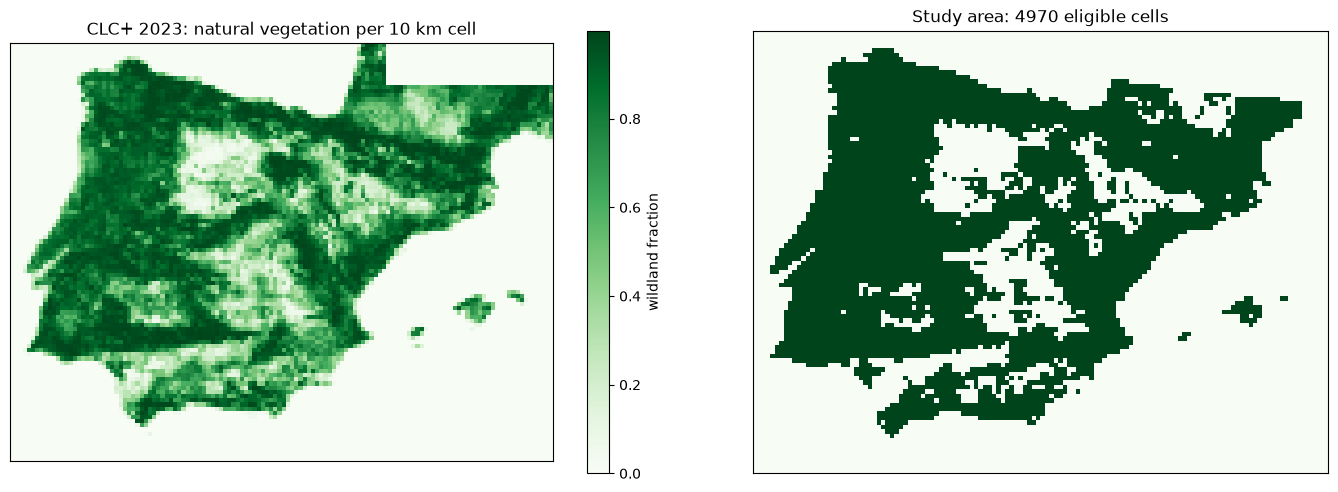

In [13]:
# The aggregated land cover: how many 10 m CLC+ pixels of each class fall in every 10 km cell
with load_source("s3", **S3_SOURCE_KWARGS).open(f"s3://{BUCKET}/{PREFIX}aux/landcover_10km_2023.npz") as f:
    lc = dict(np.load(f))

# The centre of every column and row of the study grid, and the fraction of the cell covered by each class
X = X0 + CELL * (np.arange(NX) + 0.5)
Y = Y1 - CELL * (np.arange(NY) + 0.5)
fraction = lc["counts"] / (CELL / 10) ** 2
classes = {2: "needleleaved", 3: "broadleaved_deciduous", 4: "broadleaved_evergreen",
           5: "low_woody", 6: "permanent_herbaceous"}
static = xr.Dataset({f"lc_{name}": (("y", "x"), fraction[list(lc["classes"]).index(c)])
                     for c, name in classes.items()}, coords={"x": X, "y": Y})
static["wildland_fraction"] = sum(static[v] for v in list(static.data_vars))
static["lc_trees"] = static.lc_needleleaved + static.lc_broadleaved_deciduous + static.lc_broadleaved_evergreen

# The study area: enough natural vegetation, and the centre of the cell inside the bounding box
cx, cy = np.meshgrid(X, Y)
clon, clat = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True).transform(cx, cy)
in_bbox = (clon >= BBOX[0]) & (clon <= BBOX[2]) & (clat >= BBOX[1]) & (clat <= BBOX[3])
static["eligible"] = (("y", "x"), in_bbox & (static.wildland_fraction.values >= WILDLAND_MIN_FRACTION))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
static.wildland_fraction.plot(ax=axes[0], cmap="Greens", cbar_kwargs={"label": "wildland fraction"})
static.eligible.plot(ax=axes[1], cmap="Greens", add_colorbar=False)
axes[0].set_title("CLC+ 2023: natural vegetation per 10 km cell")
axes[1].set_title(f"Study area: {int(static.eligible.sum())} eligible cells")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()

# The label: new fires

The label says, for each cell and storm day, whether a new fire appeared after the storm. It is built
from the FRP-Pixel product in three steps.

**Step 1: remove the fixed heat sources.** The product records *detections*: one hot pixel in one
10 minute image. A wildfire burns for hours or days and stops when its fuel is gone. A gas flare or a
steelworks stays hot all season. For every 1 km pixel, the days with detections are grouped into
periods, and a new period starts after a week without any. A pixel with three or more periods, or with
detections on twenty or more days, is a fixed source, and it is removed together with its eight
neighbours. The rule works pixel by pixel, so a real fire that shares a 10 km cell with a factory is
kept.

**Step 2: find where a fire could be seen.** No detection does not always mean no fire: a cloud may
have hidden it. The quality image of the product says, for every pixel and every 10 minute image,
whether a fire could have been detected (flags 0, 1 and 2). The visible pixels are counted per cell and
per image, and added up over time, so the visible share of any cell in any time window is a simple
subtraction.

**Step 3: label each cell.** Each cell has its own 48 hour window, which starts at its first flash, or
at the storm time of the day if no flash fell on it. `fire_new` is 1 if the cell has a detection inside
its window, 0 if it has none but was visible at some point, and empty if it was never visible.
`obs_fraction` stores how much of the window was visible. `burning_before` marks the cells where the
cell itself or a neighbour already had a fire in the 48 hours before the window. For every fire, the
function also keeps when it was first seen and its Fire Radiative Power, so the cube can also be used
to study how much energy the new fires release.

In [14]:
# From longitude and latitude to the 10 km grid: the functions used for every point product
to_laea = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

def to_cell(lon, lat):
    """Index of the 10 km cell containing each position (row * NX + col), -1 outside the grid."""
    fx, fy = to_laea.transform(lon, lat)
    col = np.floor((fx - X0) / CELL).astype(int)
    row = np.floor((Y1 - fy) / CELL).astype(int)
    return np.where((col >= 0) & (col < NX) & (row >= 0) & (row < NY), row * NX + col, -1)

def cell_mask(cells):
    """Boolean (y, x) grid, True in the given cells."""
    grid = np.zeros(NY * NX, bool)
    grid[cells[cells >= 0]] = True
    return grid.reshape(NY, NX)

def to_seconds(t):
    """Seconds since 1970 of a time or a series of times, whatever their unit."""
    return (pd.to_datetime(t) - pd.Timestamp("1970-01-01")) / pd.Timedelta(seconds=1)


# Every detection of the season, read in one call
lsa_keys = s3_keys("lsa509-iberia/")
LSA_DAYS = {pd.Timestamp(k[-11:-3]) for k in lsa_keys}

fires = Dataset.from_source([f"s3://{BUCKET}/{k}" for k in lsa_keys], reader="lsa509_frp",
                            product="fires", concat_dim="fire", **READ).data
det = pd.DataFrame({"line": fires.ABS_LINE.values.astype(int), "samp": fires.ABS_SAMP.values.astype(int),
                    "time": pd.to_datetime(fires.ACQTIME.values), "frp": fires.FRP.values,
                    "lon": fires.LONGITUDE_PARALLAX.values, "lat": fires.LATITUDE_PARALLAX.values})

# For every FCI pixel, its days of activity are grouped into periods separated by a week without detections
days = det.assign(day=det.time.dt.normalize())[["line", "samp", "day"]].drop_duplicates().sort_values(["line", "samp", "day"])
gap = days.groupby(["line", "samp"]).day.diff().dt.days
days["episode"] = (gap.isna() | (gap >= PERSISTENT_GAP_DAYS)).groupby([days.line, days.samp]).cumsum()
recurrence = days.groupby(["line", "samp"]).episode.max()
active_days = days.groupby(["line", "samp"]).size()

# A fixed source comes back in three periods, or is active on too many days to be a wildfire:
# it and its eight neighbours are dropped
recurrent, daily = recurrence >= PERSISTENT_MIN_EPISODES, active_days >= DAILY_SOURCE_MIN_DAYS
fixed = recurrent | daily
sources = fixed[fixed].index.to_frame(index=False)
neighbourhood = pd.concat([sources + [dl, ds_] for dl in (-1, 0, 1) for ds_ in (-1, 0, 1)]).drop_duplicates()
keep = ~pd.MultiIndex.from_frame(det[["line", "samp"]]).isin(pd.MultiIndex.from_frame(neighbourhood))

print(f"{len(det)} detections on {len(LSA_DAYS)} days | {len(sources)} fixed source pixels "
      f"({int(recurrent.sum())} recurrent, {int(daily.sum())} active on {DAILY_SOURCE_MIN_DAYS} days or more) | "
      f"{int((~keep).sum())} detections removed")
det = det[keep].reset_index(drop=True)
det["cell"] = to_cell(det.lon.values, det.lat.values)   # the cell of every detection, computed once

171685 detections on 64 days | 83 fixed source pixels (76 recurrent, 9 active on 20 days or more) | 7143 detections removed


In [15]:
# Each pixel of the quality image is placed in its 10 km cell once, from the projection written by the reader
quality = samples["LSA-509 quality"].data
geos = CRS.from_cf(quality["geostationary"].attrs)
qx, qy = np.meshgrid(quality.x.values, quality.y.values)
pixel_cell = to_cell(*Transformer.from_crs(geos, "EPSG:4326", always_xy=True).transform(qx, qy)).ravel()
inside = pixel_cell >= 0
cell_pixels = np.bincount(pixel_cell[inside], minlength=NX * NY)   # FCI pixels per cell

def observed_slots(day):
    """Slot times of one day of the fire archive, and the observable pixels of every cell in each slot."""
    flags = Dataset.from_source(lsa_path(day), reader="lsa509_frp", product="quality", **READ).data.qualityflag
    observable = flags.isin(OBSERVED_CLASSES).values.reshape(flags.sizes["time"], -1)[:, inside]
    counts = np.stack([np.bincount(pixel_cell[inside], weights=slot, minlength=NX * NY) for slot in observable])
    return flags.time.values.astype("datetime64[ns]"), counts.astype(np.int32)

# Only the days inside the label windows of the episodes built in this run are needed
built = EPISODES if BUILD_CUBE else [DEMO_EPISODE]
OBS_DAYS = sorted({t for e in built for t in pd.date_range(e, periods=3)} & LSA_DAYS)
times, counts = zip(*(observed_slots(day) for day in OBS_DAYS))
OBS_TIMES = np.concatenate(times)
OBS_CUM = np.vstack([np.zeros((1, NX * NY), np.int32),
                     np.cumsum(np.concatenate(counts), axis=0, dtype=np.int32)])   # running total per cell
assert np.all(np.diff(OBS_TIMES) > np.timedelta64(0, "ns")), "quality slots must increase in time"
print(f"{len(OBS_DAYS)} days, {len(OBS_TIMES)} quality slots")

def observed_in_window(start, span):
    """Observable pixel slots of every cell between its own start time and start + span."""
    first, last = np.searchsorted(OBS_TIMES, start), np.searchsorted(OBS_TIMES, start + span)
    cells = np.arange(NX * NY)
    return OBS_CUM[last, cells] - OBS_CUM[first, cells]

3 days, 419 quality slots


In [16]:
# Labels one episode. Every cell has its own label window: 48 h from its first flash, or from the storm
# time of the day when no flash fell on it. fire_new: 1 = new fire detected, 0 = observed without fire,
# NaN = never observable. Also returns the energy of each fire and the flags that define the sample.

def label_episode(day, start):
    """Label, fire identity and energy, earlier fire and observability of every cell, from its start time."""
    d = pd.Timestamp(day)
    t0 = pd.to_datetime(start.ravel(), unit="s").values.astype("datetime64[ns]")
    span, prior = np.timedelta64(LABEL_HOURS, "h"), np.timedelta64(PRIOR_HOURS, "h")
    near = det[det.time.between(d - pd.Timedelta(hours=PRIOR_HOURS), d + pd.Timedelta(days=3), inclusive="left")
               & (det.cell >= 0)]
    when = near.time.values.astype("datetime64[ns]")

    # A fire is new in a cell when it is first seen inside the label window of that cell
    own_start = t0[near.cell.values]
    window = near[(when >= own_start) & (when < own_start + span)]
    by_cell = window.groupby("cell").agg(fire_first=("time", "min"), frp_sum=("frp", "sum"),
                                         frp_max=("frp", "max"), n_det=("frp", "size"))
    # The power of each fire summed over the 24 h after it was first seen: the same span for every fire
    follow = det.join(by_cell.fire_first.rename("first"), on="cell", how="inner")
    follow = follow[(follow.time >= follow["first"]) & (follow.time < follow["first"] + pd.Timedelta(hours=24))]
    by_cell["frp_24h"] = follow.groupby("cell").frp.sum()
    by_cell["fire_first"] = to_seconds(by_cell.fire_first)
    layers = {}
    for name, values in by_cell.items():
        grid = np.full(NY * NX, np.nan)
        grid[values.index] = values.values
        layers[name] = grid.reshape(NY, NX)

    # Burning before: a detection in the cell or in one of its eight neighbours in the 48 h before its start,
    # so that a fire spreading in from next door is not taken for a new one
    burning = np.zeros(NY * NX, bool)
    row, col = near.cell.values // NX, near.cell.values % NX
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            r, c = row + dr, col + dc
            ok = (r >= 0) & (r < NY) & (c >= 0) & (c < NX)
            target = r[ok] * NX + c[ok]
            hit = (when[ok] >= t0[target] - prior) & (when[ok] < t0[target])
            burning[target[hit]] = True

    # Observability: the share of the pixel slots of the window in which a fire could have been seen
    observed = observed_in_window(t0, span)
    obs_fraction = np.full(NY * NX, np.nan)
    has_pixels = cell_pixels > 0
    obs_fraction[has_pixels] = observed[has_pixels] / (cell_pixels[has_pixels] * SLOTS_PER_WINDOW)

    fire = cell_mask(window.cell.values).ravel()
    return {
        "fire_new": np.where(fire, 1.0, np.where(observed > 0, 0.0, np.nan)).reshape(NY, NX),
        "burning_before": burning.reshape(NY, NX),
        "obs_fraction": obs_fraction.reshape(NY, NX),
        "label_start": start,
        "prior_complete": all(t in LSA_DAYS for t in pd.date_range(d - pd.Timedelta(days=2), periods=2)),
        **layers,
    }

# The features of a storm day

**Lightning.** The flash product has one file every 10 minutes, 144 a day, and each file is a list
of flashes. The files are read one by one and joined into one table, which is the reliable way to read
this kind of product with DEFAIR. Each flash is moved back from the ground to a height of 10 km to
correct the parallax, and the flashes of the day are counted into the cells. Four things come out of
them:

```
exposure      did the cell get at least one flash?
storm         number of flashes, and their mean duration, size and number of light pulses
first flash   when the first flash fell in the cell: the start of its window
onset         the storm time of the day: the median time of the first flash over the wildland
              cells with lightning. Each cell counts once, so a few flashes at night do not move it.
              It starts the window of the cells without lightning and sets the time of the GII
```

**The atmosphere before the storm.** The GII describes how much water the air held and how unstable
it was, which decides whether a storm brings rain with its lightning (RQ2 explains why this matters). The satellite can only measure the GII where the sky is clear,
because a cloud hides the air below it. During the storm, the cells with lightning are under thick
cloud. So we look at the air **before** the storm:

```
          onset - 3 h                  onset - 1 h           onset
   ────────────|────────────────────────────|────────────────────|────▶ time
               └──── GII read every 10 min ─┘   left out:        storm
                     last clear value kept      clouds already   begins
                     for each pixel             building up
```

The onset is one time for the whole study area, not one per cell, so for a cell that the storm
reaches late in the day the GII describes the air of the morning.

Each GII file is missing coordinates for a slightly different set of pixels, so the coordinates of
all the files are combined first, and the result is cropped once to the study area. The files are
found by the number of their 10 minute slot in the day, written between underscores in the name so
that it cannot be confused with the digits of the date.

**Fuel and rain, and the alignment.** The Fire Risk Map, the rain and the GII each give one map per
episode, but on three different grids. Before joining them, each one is given the date of the
episode, because each product writes its date differently. Then a single DEFAIR alignment call puts
all three on the study grid and merges them into one dataset. DEFAIR adds the product name in front
of each variable, so we pick variables by the end of their name.

**Why an average.** A 10 km cell holds about seven SEVIRI pixels over Iberia, and a storm may cover only a
few of them. The fair value for the cell is the average of all its pixels, not the value at its
centre. DEFAIR's methods (nearest, bilinear, cubic) all estimate the value at the centre, so the
average is built in two steps:

```
source pixels ──▶ 1 km grid (nearest: each pixel copied onto the 1 km cells it covers)
              ──▶ 10 km grid (average of each 10 x 10 block of 1 km cells)
```

Where part of a cell has no data, at the coast or in a gap of a source, the average uses only the
1 km cells that have data.

The following code snippets describe these processes.

In [17]:
# Lightning: the flashes of the episode day, corrected for parallax, counted and described in every cell
LFL_FIELDS = ["flash_time", "longitude", "latitude", "flash_duration", "flash_footprint", "number_of_events"]

# The Lightning Imager places each flash where its line of sight meets the ground. The flash is moved back
# along that line to the height of the cloud: over Iberia about 10 km to the south
A_WGS84, B_WGS84 = 6378137.0, 6356752.314245
TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
SATELLITE = np.array(TO_ECEF.transform(SAT_LON, 0.0, SAT_HEIGHT))

def parallax_correct(lon, lat, height=PARALLAX_HEIGHT):
    """Position of each flash where the line of sight of the satellite crosses the given height."""
    ground = np.stack(TO_ECEF.transform(lon, lat, np.zeros_like(lon)), axis=-1)
    view = ground - SATELLITE
    w = np.array([1 / (A_WGS84 + height) ** 2, 1 / (A_WGS84 + height) ** 2, 1 / (B_WGS84 + height) ** 2])
    qa, qb, qc = (w * view ** 2).sum(-1), 2 * (w * SATELLITE * view).sum(-1), (w * SATELLITE ** 2).sum() - 1
    t = (-qb - np.sqrt(qb ** 2 - 4 * qa * qc)) / (2 * qa)        # first crossing of the shell at that height
    x, y, z = (SATELLITE + t[:, None] * view).T
    lon_c, lat_c, _ = TO_GEODETIC.transform(x, y, z)
    return lon_c, lat_c

# Check: a flash seen over the centre of Iberia moves about 10 km south, towards the point under the satellite
lon_c, lat_c = parallax_correct(np.array([-4.0]), np.array([40.0]))
azimuth, _, shift = Geod(ellps="WGS84").inv(-4.0, 40.0, lon_c[0], lat_c[0])
print(f"parallax correction at 4 W, 40 N: {shift / 1000:.1f} km towards azimuth {azimuth:.0f} deg")

def read_flashes(day):
    """All flashes of the episode day inside the study area, corrected for parallax, as a table."""
    # The 144 slots of the day are read one by one: the multifile concatenation degenerates on point products
    tables = []
    for key in s3_keys(f"lfl-orig/{day}/"):
        f = Dataset.from_source(f"s3://{BUCKET}/{key}", reader="mtg_li_lfl", **READ).data
        tables.append(pd.DataFrame({v: np.ravel(f[v].values) for v in LFL_FIELDS}))
    fl = pd.concat(tables, ignore_index=True)
    # One slot starts before midnight, so the flashes are cut to the calendar day
    d = pd.Timestamp(day)
    fl = fl[fl.flash_time.between(d, d + pd.Timedelta(days=1), inclusive="left")].copy()
    fl["longitude"], fl["latitude"] = parallax_correct(fl.longitude.values.astype(float), fl.latitude.values.astype(float))
    return fl[fl.longitude.between(BBOX[0], BBOX[2]) & fl.latitude.between(BBOX[1], BBOX[3])]

def lightning_features(fl):
    """Storm descriptors of every cell: count, duration, footprint, events per flash and first flash."""
    g = fl.assign(cell=to_cell(fl.longitude.values, fl.latitude.values)).query("cell >= 0").groupby("cell")
    stats = pd.DataFrame({"lfl_flash_count": g.size(),
                          "lfl_duration_mean": g.flash_duration.mean(),
                          "lfl_footprint_mean": g.flash_footprint.mean(),
                          "lfl_events_per_flash": g.number_of_events.mean(),
                          "lfl_first": to_seconds(g.flash_time.min())})
    # A cell without flashes counts zero of them, but has no duration, footprint or first flash
    out = {}
    for name, values in stats.items():
        grid = np.full(NY * NX, 0.0 if name == "lfl_flash_count" else np.nan)
        grid[values.index] = values.values
        out[name] = grid.reshape(NY, NX)
    return out

def storm_time(first_flash):
    """The storm time of the day: the median first flash over the wildland cells with lightning."""
    first = first_flash[static.eligible.values & np.isfinite(first_flash)]
    return pd.to_datetime(np.median(first), unit="s")

parallax correction at 4 W, 40 N: 10.5 km towards azimuth 174 deg


In [18]:
# Atmosphere: the instability indices of the last clear sky before the storm
CROP = {"lat_min": BBOX[1] - MARGIN, "lat_max": BBOX[3] + MARGIN,
        "lon_min": BBOX[0] - MARGIN, "lon_max": BBOX[2] + MARGIN}
GII_VARS = ["k_index", "lifted_index", "prec_water_total"]

def gii_before_onset(day, onset):
    """Last clear GII value per pixel between 3 h and 1 h before the onset, as a DEFAIR Dataset."""
    d = pd.Timestamp(day)
    slots = pd.date_range((onset - GII_FROM).floor("10min"), (onset - GII_TO).floor("10min"), freq="10min")
    last_clear = lat = lon = None
    # Slot after slot, every pixel keeps the most recent value it had under clear sky
    for s in slots[slots >= d]:
        cycle = f"{(s - d) // pd.Timedelta(minutes=10) + 1:04d}"
        try:
            gii_ds = Dataset.from_source(f"s3://{BUCKET}/{PREFIX}gii-orig/{d:%Y%m%d}/*_{cycle}_????.nc",
                                         reader="mtg_l2_gii", **READ)
        except FileNotFoundError:
            continue                                        # slot missing from the archive
        g = gii_ds.transform("content_filter", include_vars=GII_VARS).data.isel(time=0, drop=True)
        lat = g.lat if lat is None else lat.fillna(g.lat)   # each file leaves a different set of pixels without position
        lon = g.lon if lon is None else lon.fillna(g.lon)
        g = g.drop_vars(["lat", "lon"])
        last_clear = g if last_clear is None else g.where(g.notnull(), last_clear)
    if last_clear is None:
        return None                                         # no GII slot available before the onset
    # The crop comes last, on the positions joined from every slot, so that all of them share one window
    inside_crop = ((lat >= CROP["lat_min"]) & (lat <= CROP["lat_max"]) &
                   (lon >= CROP["lon_min"]) & (lon <= CROP["lon_max"])).values
    rows, cols = np.flatnonzero(inside_crop.any(axis=1)), np.flatnonzero(inside_crop.any(axis=0))
    window = {"y": slice(rows[0], rows[-1] + 1), "x": slice(cols[0], cols[-1] + 1)}
    last_clear = last_clear.assign_coords(lat=lat, lon=lon).isel(window)
    return Dataset(last_clear.expand_dims(time=[d]))

In [19]:
# Fuel, rain and atmosphere: three grids brought onto one, and averaged into the 10 km cells
GRIDDED = {"frm_fwi": "FWI", "frm_ffmc": "FFMC", "frm_dmc": "DMC", "frm_dc": "DC",
           "h61_precip": "acc_rr",
           "gii_k_index": "k_index", "gii_lifted_index": "lifted_index", "gii_prec_water_total": "prec_water_total"}

def pick(ds_aligned, suffix):
    """The variable whose name ends with suffix, or NaN everywhere if the source was not available."""
    match = [v for v in ds_aligned.data_vars if v.endswith(suffix)]
    return ds_aligned[match[0]].values if match else np.full((NY, NX), np.nan)

def gridded_features(day, gii):
    """FRM, H61B and the pre storm GII of one episode, aligned at 1 km and averaged into the 10 km cells."""
    d = pd.Timestamp(day)
    # The three products describe the same episode but each writes its date differently
    stamp = lambda source: Dataset(source.data.assign_coords(time=[d]))
    frm = stamp(Dataset.from_source(frm_path(day), reader="lsa_frm", **READ))
    h61 = stamp(Dataset.from_source(h61_path(day), reader="hsaf_h61", **READ))
    # One call brings the three grids onto the fine grid; the 10 x 10 average then gives the cell mean
    with AlignmentPlugin() as plugin:
        fine = plugin.transform(frm, target=GRID_1KM, datasets=[h61] + ([gii] if gii else []),
                                spatial_method=SPATIAL_METHOD).data.isel(time=0, drop=True)
    aligned = fine.coarsen(x=FACTOR, y=FACTOR).mean().compute()
    assert np.allclose(aligned.x, X) and np.allclose(aligned.y, Y)
    return {name: pick(aligned, suffix) for name, suffix in GRIDDED.items()}

# Building the cube

The builder puts the pieces together for one storm day. The flashes give the exposure, the storm
description, the first flash of every cell and the onset. The onset sets the time window of the GII.
The alignment brings fuel, rain and air onto the grid. The label comes from the cleaned fire
detections, inside the window of each cell. Every piece ends as a (y, x) map, so a storm day is a plain
xarray dataset with one extra dimension, `episode`, of length one.

## The builder, live

The cell below builds one storm day from the raw products, exactly as every day of the campaign is
built, and shows the result.

In [20]:
def build_episode(day):
    """The cube of one episode: every source on the 10 km grid, one (y, x) layer per variable."""
    d = pd.Timestamp(day)
    fl = read_flashes(day)
    lightning = lightning_features(fl)
    onset = storm_time(lightning["lfl_first"])
    # The label window of every cell starts at its first flash, or at the storm time without one
    start = np.where(np.isnan(lightning["lfl_first"]), to_seconds(onset), lightning["lfl_first"])
    label = label_episode(day, start)
    prior_complete = label.pop("prior_complete")
    layers = gridded_features(day, gii_before_onset(day, onset)) | lightning | label
    ep = xr.Dataset({name: (("y", "x"), values) for name, values in layers.items()}, coords={"x": X, "y": Y})
    ep["exposed"] = ep.lfl_flash_count > 0
    return ep.expand_dims(episode=[d]).assign_coords(onset=("episode", [onset]),
                                                     prior_complete=("episode", [prior_complete]))

t0 = time.time()
demo = build_episode(DEMO_EPISODE)
print(f"{DEMO_EPISODE} built in {time.time() - t0:.0f} s | cells with lightning: {int(demo.exposed.sum())} | "
      f"new fires: {int((demo.fire_new == 1).sum())} | burning before: {int(demo.burning_before.sum())} | "
      f"median visible share: {float(demo.obs_fraction.median()):.2f} | onset: {pd.Timestamp(demo.onset.values[0]):%H:%M} UTC")
demo

2026-08-10 built in 48 s | cells with lightning: 1402 | new fires: 84 | burning before: 729 | median visible share: 0.52 | onset: 14:28 UTC


<xarray.Dataset> Size: 2MB
Dimensions:               (episode: 1, y: 100, x: 130)
Coordinates:
  * episode               (episode) datetime64[us] 8B 2026-08-10
    onset                 (episode) datetime64[ns] 8B 2026-08-10T14:28:56.556...
    prior_complete        (episode) bool 1B True
  * y                     (y) float64 800B 2.495e+06 2.485e+06 ... 1.505e+06
  * x                     (x) float64 1kB 2.605e+06 2.615e+06 ... 3.895e+06
Data variables: (12/23)
    frm_fwi               (episode, y, x) float32 52kB nan nan ... 63.67 55.56
    frm_ffmc              (episode, y, x) float32 52kB nan nan ... 97.01 96.19
    frm_dmc               (episode, y, x) float32 52kB nan nan ... 359.4 307.1
    frm_dc                (episode, y, x) float32 52kB nan nan ... 858.6 838.2
    h61_precip            (episode, y, x) float64 104kB 0.0 0.0 ... 7.266 8.478
    gii_k_index           (episode, y, x) float32 52kB 7.9 8.341 ... 27.92 26.62
    ...                    ...
    fire_first            (episode, y, x) float64 104kB nan nan nan ... nan nan
    frp_sum               (episode, y, x) float64 104kB nan nan nan ... nan nan
    frp_max               (episode, y, x) float64 104kB nan nan nan ... nan nan
    n_det                 (episode, y, x) float64 104kB nan nan nan ... nan nan
    frp_24h               (episode, y, x) float64 104kB nan nan nan ... nan nan
    exposed               (episode, y, x) bool 13kB False False ... False False

## The campaign and the consolidation

The same builder runs once for each storm day, and each finished day is saved to its own Zarr store on
disk. A day already on disk is skipped, so the run can be stopped and resumed at any time. The 37 days
are then joined into one cube along the `episode` dimension, and the land cover, which is the same
every day, is added once.

**One fire, one storm day.** Storm days often follow each other, and each window lasts 48 hours, so the
windows overlap. A fire that starts in the overlap would be counted twice, sometimes once with lightning
and once without. Each fire is recognised by the moment it was first seen in its cell, and it is given
to one day only: the one whose window started last before the fire appeared, the most recent storm.

```
             Aug 10        Aug 11        Aug 12        Aug 13
day A            |=== window, 48 h ===============|
                 ^ first flash of A in the cell
day B                          |=== window, 48 h ===============|
                               ^ first flash of B in the cell
                                            * fire first seen (Aug 12)

   both windows contain the fire  ->  it goes to day B, whose window started last
   on day A this cell is left out
```

**The final sample.** A cell on a storm day enters the analysis only if all of this is true:

```
eligible          it is a wildland cell of the study area
visible           fire detection was possible in at least a quarter of its window
not burning       no fire in the cell or its neighbours in the 48 hours before its window
complete prior    the fire archive has both days before the storm day
its own fire      its fire is not already counted on another day
```

The result is stored in the cube as `in_sample`, so anyone using the cube gets the same sample. The
whole cube of this study has already been built and published, so with `BUILD_CUBE = False` this cell
does nothing and the published cube is read below.

In [21]:
# Consolidation: the 37 episodes in one cube, and each fire given to a single episode
def repeated_fires(cube, sample, prefer_exposed=False, drop_mixed=False):
    """True where the fire of the cell is left out because it falls in the windows of several episodes.
    It is kept in the episode whose window started last; with prefer_exposed, in the last episode with
    lightning in the cell; with drop_mixed, a fire shared by episodes with and without lightning in the
    cell is left out of all of them."""
    t = (xr.Dataset({"fire_first": cube.fire_first.where(sample), "start": cube.label_start, "exposed": cube.exposed})
         .to_dataframe().dropna(subset=["fire_first"]).reset_index())
    t["key"] = t.start + (1e10 * t.exposed if prefer_exposed else 0)
    owner = t.loc[t.groupby(["y", "x", "fire_first"]).key.idxmax(), ["y", "x", "fire_first", "episode"]]
    dup = t.merge(owner.rename(columns={"episode": "owner"}), on=["y", "x", "fire_first"]).query("episode != owner")
    if drop_mixed:
        mixed = t.groupby(["y", "x", "fire_first"]).exposed.transform("nunique") > 1
        dup = pd.concat([dup, t[mixed]])

    mask = np.zeros(cube.fire_new.shape, bool)
    mask[pd.Index(cube.episode.values).get_indexer(dup.episode),
         pd.Index(cube.y.values).get_indexer(dup.y),
         pd.Index(cube.x.values).get_indexer(dup.x)] = True
    return xr.DataArray(mask, coords=cube.fire_new.coords, dims=cube.fire_new.dims)


if BUILD_CUBE:
    for day in EPISODES:
        store = CUBE_DIR / f"episode_{day}.zarr"
        if not store.exists():
            t0 = time.time()
            build_episode(day).to_zarr(store, mode="w")
            print(f"{day}  {time.time() - t0:.0f} s")

    cube = xr.concat([xr.open_zarr(CUBE_DIR / f"episode_{d}.zarr") for d in EPISODES], dim="episode")
    cube = xr.merge([cube, static]).load()
    observable = cube.fire_new.notnull() & (cube.obs_fraction >= MIN_OBS_FRACTION)
    base = cube.eligible & observable & ~cube.burning_before & cube.prior_complete
    cube["fire_repeated"] = repeated_fires(cube, base)
    cube["in_sample"] = base & ~cube.fire_repeated

    print(dict(cube.sizes))
    print(f"storm days with a complete prior window: {int(cube.prior_complete.sum())} of {cube.sizes['episode']}")
    print(f"distinct fires: {int((cube.fire_new == 1).where(cube.in_sample).sum())}, "
          f"repeated: {int(cube.fire_repeated.sum())}")
else:
    print("BUILD_CUBE is False: the campaign and the consolidation are skipped, the published cube is read below")

BUILD_CUBE is False: the campaign and the consolidation are skipped, the published cube is read below


# Publication

With `BUILD_CUBE = True`, the cube is written to disk and uploaded to the bucket one file at a time.
Then the cell does what any user of the data would do: it reads the published cube straight from S3
with one `open_zarr` call. It also reports how much of the study area the GII covers on each day, since
it only exists under clear sky. Everything after this point works only with that cube.

Anyone can open the same cube outside this notebook with that one call:

```python
cube = xr.open_zarr("s3://defair-use-case/cubes/fireignition_cube.zarr",
                    storage_options={"anon": True,
                                     "client_kwargs": {"endpoint_url": "https://s3.central.data.destination-earth.eu"}})
```

In [22]:
if BUILD_CUBE:
    for v in cube.variables:
        cube[v].encoding = {}
    cube.to_zarr(LOCAL_CUBE, mode="w")

    t0 = time.time()
    n = 0
    try:
        for root, _, files in os.walk(LOCAL_CUBE):
            for f in files:
                path = os.path.join(root, f)
                s3_write.upload_file(path, BUCKET, PREFIX + CUBE_KEY + os.path.relpath(path, LOCAL_CUBE))
                n += 1
    except Exception:
        raise PermissionError(f"the cube was built but could not be uploaded to {BUCKET}: this account "
                              f"has read access only. It is saved locally at {LOCAL_CUBE}.")
    print(f"{n} objects uploaded in {time.time() - t0:.0f} s")

cube = xr.open_zarr(f"s3://{BUCKET}/{PREFIX}{CUBE_KEY}", storage_options=STORAGE_OPTIONS).load()
print(dict(cube.sizes))
print(f"{len(cube.data_vars)} variables: {', '.join(cube.data_vars)}")

coverage = cube.gii_prec_water_total.notnull().where(cube.eligible).mean(("y", "x"))
print(f"GII coverage of the study area per episode: median {float(coverage.median()):.0%}, "
      f"from {float(coverage.min()):.0%} to {float(coverage.max()):.0%}")

{'episode': 37, 'y': 100, 'x': 130}
33 variables: burning_before, eligible, exposed, fire_first, fire_new, fire_repeated, frm_dc, frm_dmc, frm_ffmc, frm_fwi, frp_24h, frp_max, frp_sum, gii_k_index, gii_lifted_index, gii_prec_water_total, h61_precip, in_sample, label_start, lc_broadleaved_deciduous, lc_broadleaved_evergreen, lc_low_woody, lc_needleleaved, lc_permanent_herbaceous, lc_trees, lfl_duration_mean, lfl_events_per_flash, lfl_first, lfl_flash_count, lfl_footprint_mean, n_det, obs_fraction, wildland_fraction
GII coverage of the study area per episode: median 97%, from 72% to 100%


## One grid, every source

The figure stacks the layers of the most active episode of the season as planes over the same 10 km
footprint, bottom to top: the land cover that defines the study area, the fuel, the rain, the
atmosphere before the storm, the lightning and, on top, the new fires that followed. Each plane is
coloured by its own range. Eight layers from six products and four providers, and the cells line up
exactly, because they are the same cells: that alignment is the whole point of the cube, and it is
what makes the question of this study answerable at all.

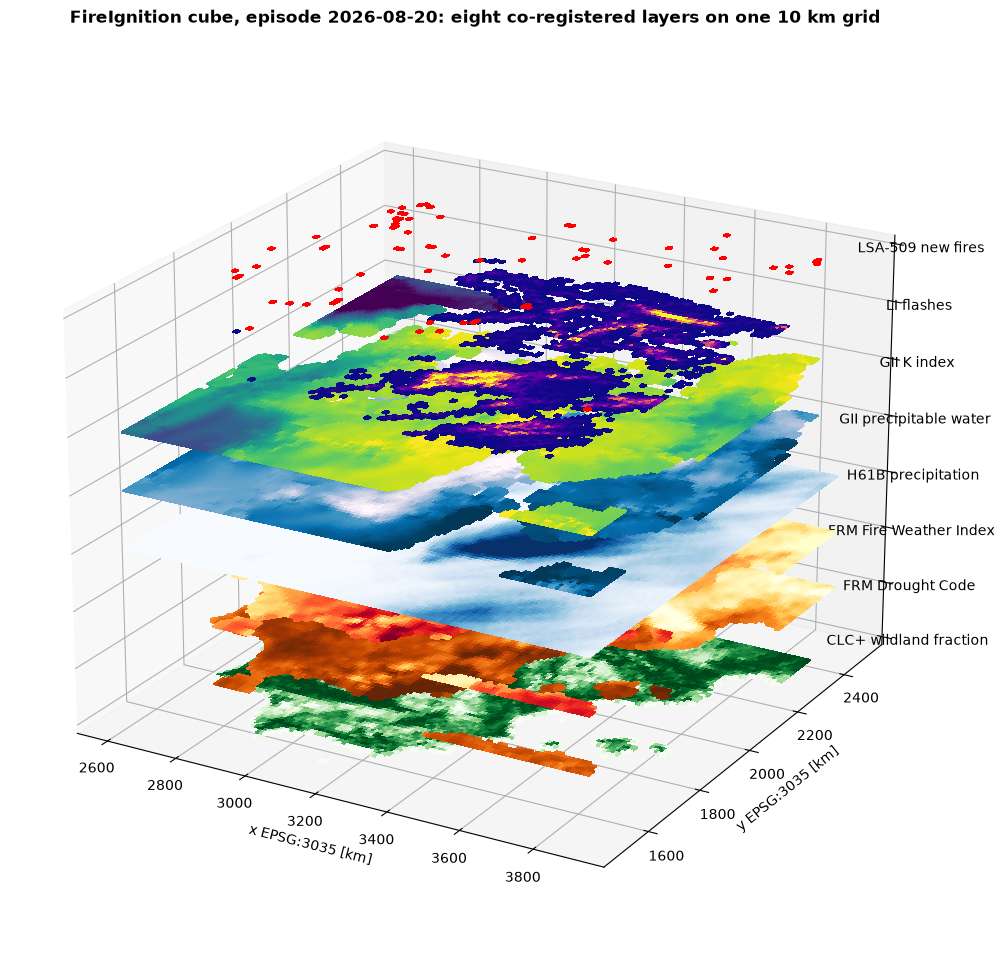

In [23]:
showcase = cube.lfl_flash_count.sum(("y", "x")).idxmax("episode").values
ep = cube.sel(episode=showcase)
layers = [
    ("CLC+ wildland fraction", cube.wildland_fraction.where(cube.wildland_fraction > 0), "Greens"),
    ("FRM Drought Code", ep.frm_dc, "YlOrBr"),
    ("FRM Fire Weather Index", ep.frm_fwi, "YlOrRd"),
    ("H61B precipitation", ep.h61_precip, "Blues"),
    ("GII precipitable water", ep.gii_prec_water_total, "PuBu"),
    ("GII K index", ep.gii_k_index, "viridis"),
    ("LI flashes", ep.lfl_flash_count.where(ep.lfl_flash_count > 0), "plasma"),
    ("LSA-509 new fires", ep.fire_new.where(ep.fire_new == 1), "autumn"),
]

xs, ys = np.meshgrid(cube.x / 1000, cube.y / 1000)
fig = plt.figure(figsize=(12, 13))
ax = fig.add_subplot(projection="3d")
for z, (name, field, cmap) in enumerate(layers):
    data = field.values.astype(float)
    valid = data[np.isfinite(data)]
    if valid.size == 0:
        continue
    norm = mcolors.Normalize(*np.percentile(valid, [2, 98]))
    colors = plt.get_cmap(cmap)(norm(data))
    colors[~np.isfinite(data)] = 0                      # transparent where there is no data
    ax.plot_surface(xs, ys, np.full(xs.shape, z), facecolors=colors,
                    rstride=1, cstride=1, shade=False, antialiased=False)

ax.set_zticks(range(len(layers)))
ax.set_zticklabels([name for name, *_ in layers])
ax.set_xlabel("x EPSG:3035 [km]")
ax.set_ylabel("y EPSG:3035 [km]")
ax.set_title(f"FireIgnition cube, episode {str(showcase)[:10]}: eight co-registered layers on one 10 km grid",
             fontweight="bold")
ax.view_init(elev=22, azim=-60)
plt.show()

# Analysis

From here on the notebook only uses the published cube. The cell below turns it into a table with one
row per cell and storm day of the sample, adding three columns: the identity of the cell, so that a cell
can be compared with itself on other days; the rain class of that day; and the day of the season.

It also shows how the sample was built. The first table follows all the cells of all the storm days
through each condition of the sample, in order, and shows at every step how many remain, how many had
lightning and how many new fires they hold.

In [24]:
eligible = cube.eligible.broadcast_like(cube.fire_new)
steps = {
    "wildland cell of the study area": eligible,
    "visible in at least a quarter of its window": cube.fire_new.notnull() & (cube.obs_fraction >= MIN_OBS_FRACTION),
    "no fire nearby in the 48 h before": ~cube.burning_before,
    "complete prior archive": cube.prior_complete.broadcast_like(cube.fire_new),
    "fire not counted on another day": ~cube.fire_repeated,
}
mask, rows = xr.ones_like(eligible, dtype=bool), []
for step, condition in steps.items():
    mask = mask & condition
    rows.append({"step": step, "cell episodes": int(mask.sum()),
                 "with lightning": int((mask & cube.exposed).sum()),
                 "new fires": int((mask & (cube.fire_new == 1)).sum())})
display(pd.DataFrame(rows).set_index("step"))
assert int(mask.sum()) == int(cube.in_sample.sum())

COLUMNS = ["h61_precip", "frm_ffmc", "frm_dmc", "frm_dc", "frm_fwi", "gii_prec_water_total", "lfl_flash_count",
           "lfl_duration_mean", "lc_trees", "exposed", "fire_new", "obs_fraction", "fire_first", "label_start"]

RR_COLUMNS = ["exposed", "fire_new", "h61_precip"]

def sample_table(c, sample, columns):
    """One row per cell episode of the sample, with the identity of the cell and its rain class."""
    t = c[columns].where(sample).to_dataframe().dropna(subset=["fire_new"]).reset_index()
    t["cell"] = ((Y1 - t.y) // CELL).astype(int) * NX + ((t.x - X0) // CELL).astype(int)
    t["rain_class"] = pd.cut(t.h61_precip, RAIN_BINS, labels=RAIN_LABELS)
    return t

table = sample_table(cube, cube.in_sample, COLUMNS)
table["season_day"] = (pd.to_datetime(table.episode) - pd.Timestamp(EPISODES[0])).dt.days

print(f"{len(table)} cell episodes in the sample, {table.episode.nunique()} episodes, "
      f"{table.cell.nunique()} distinct cells")
print(f"new fires: {int(table.fire_new.sum())}, of them in cells with lightning: "
      f"{int((table.fire_new * table.exposed).sum())}")

,cell episodes,with lightning,new fires
step,,,
wildland cell of the study area,183890,18838,2114
visible in at least a quarter of its window,169396,15664,2042
no fire nearby in the 48 h before,156208,14610,1316
complete prior archive,156208,14610,1316
fire not counted on another day,155779,14575,887


155779 cell episodes in the sample, 37 episodes, 4960 distinct cells
new fires: 887, of them in cells with lightning: 100


## A first look: cells with and without lightning

The table compares the two groups of the sample: how many there are, how often they had a new fire, how
much rain they got, and how much of their window the satellite could see. The figure shows the new fire
rate of each group in each rain class, with the number of cells on each bar.

This first look already shows why a direct comparison would mislead: cells with lightning get much more
rain, and rain puts out fires. That is why RQ1 compares each cell only with itself, under similar rain.

,cell episodes,new fire rate,median rain [mm],share above 1 mm,median visible share
without lightning,141204,0.006,0.00,0.161,0.752
with lightning,14575,0.007,8.33,0.824,0.556


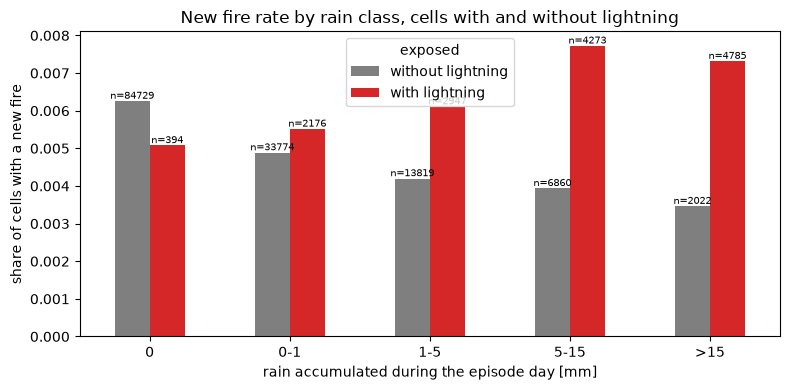

In [25]:
exposed_group = table.exposed.astype(bool)
groups = table.groupby(exposed_group)
summary = pd.DataFrame({
    "cell episodes": groups.size(),
    "new fire rate": groups.fire_new.mean(),
    "median rain [mm]": groups.h61_precip.median(),
    "share above 1 mm": groups.h61_precip.apply(lambda rain: (rain > 1).mean()),
    "median visible share": groups.obs_fraction.median(),
})
summary.index = ["without lightning", "with lightning"]
display(summary.round(3))

names = {False: "without lightning", True: "with lightning"}
by_rain = table.groupby(["rain_class", exposed_group], observed=True).fire_new
rates, counts = by_rain.mean().unstack().rename(columns=names), by_rain.size().unstack().rename(columns=names)
ax = rates.plot.bar(figsize=(8, 4), color=["tab:grey", "tab:red"], rot=0)
for bars, column in zip(ax.containers, rates.columns):
    ax.bar_label(bars, labels=[f"n={n:.0f}" if n == n else "" for n in counts[column]], fontsize=7)
ax.set_xlabel("rain accumulated during the episode day [mm]")
ax.set_ylabel("share of cells with a new fire")
ax.set_title("New fire rate by rain class, cells with and without lightning")
plt.tight_layout()

## RQ1: is lightning followed by more new fires?

**The relative risk.** RQ1 comes down to one number: the share of cells with lightning that had a new
fire, divided by the share of cells without lightning that had one. A value of 1 means lightning makes
no difference. Above 1, cells hit by lightning burn more often.

**Comparing like with like.** The **Mantel-Haenszel estimator** (Mantel and Haenszel, 1959) splits the
data into small groups, called strata, makes the comparison inside each one, and then combines them,
giving more weight to the larger ones. Here each stratum is one cell under one rain class, so a cell
with lightning is only compared with the same cell on days with similar rain and no lightning. Only the strata that contain both days with lightning and days without it, and at least one fire, contribute to the estimate; the cell below counts them. The crude relative risk, without this correction, is printed for contrast.

**How sure we are.** Cells of the same day share the same storm and weather, so they are not
independent. The uncertainty is therefore measured by resampling whole storm days: the 37 days are drawn
at random, with replacement, 1000 times, and the relative risk is recomputed each time. This is a
**cluster bootstrap**, and the 95 % interval covers the middle 95 % of those values. The last two lines
recompute the estimate with two other rules for fires that fall on two days. Giving them to the last
storm with lightning in the cell can only push the estimate up. Leaving out every fire shared by a day
with lightning and a day without it pushes it down, because it also removes the fires that lightning
lights on consecutive storm days. The main rule sits between the two.

In [26]:
def strata(df):
    """Fires and cells with and without lightning in every stratum of the study design."""
    return (df.assign(n1=df.exposed, n0=1 - df.exposed, a=df.fire_new * df.exposed, c=df.fire_new * (1 - df.exposed))
              .groupby(STRATA, observed=True)[["a", "c", "n1", "n0"]].sum())

def mantel_haenszel_rr(df):
    """Relative risk of the exposed cells, pooled over the strata of the study design."""
    s = strata(df)
    n = s.n1 + s.n0
    denominator = (s.c * s.n1 / n).sum()
    return (s.a * s.n0 / n).sum() / denominator if denominator > 0 else np.nan   # nan: no fire without lightning

def episode_bootstrap(df, stat, n):
    """The statistic recomputed on n resamples of whole episodes, drawn with replacement."""
    rng = np.random.default_rng(SEED)
    parts = [g for _, g in df.groupby("episode")]
    return np.array([stat(pd.concat([parts[i] for i in rng.integers(0, len(parts), len(parts))])) for _ in range(n)])

def plot_intervals(ax, estimate, low, high, labels, horizontal=False):
    """Estimates with their 95 % intervals, and a dashed line at 1, the value of no effect."""
    pos, err = np.arange(len(estimate)), [np.asarray(estimate - low), np.asarray(high - estimate)]
    if horizontal:
        ax.errorbar(estimate, pos, xerr=err, fmt="o", color="k")
        ax.axvline(1, ls="--", color="grey")
        ax.set_yticks(pos, labels)
    else:
        ax.errorbar(pos, estimate, yerr=err, fmt="o", color="k")
        ax.axhline(1, ls="--", color="grey")
        ax.set_xticks(pos, labels)

rr = mantel_haenszel_rr(table)
boot = episode_bootstrap(table, mantel_haenszel_rr, N_BOOT_RR)
low, high = np.nanpercentile(boot, [2.5, 97.5])

s = strata(table)
informative = int(((s.n1 > 0) & (s.n0 > 0) & (s.a + s.c > 0)).sum())
n1, n0 = table.exposed.sum(), (1 - table.exposed).sum()
a, c = (table.fire_new * table.exposed).sum(), (table.fire_new * (1 - table.exposed)).sum()
print(f"exposed cells: {int(n1)}, new fire rate {a / n1:.4f}")
print(f"unexposed cells: {int(n0)}, new fire rate {c / n0:.4f}")
print(f"crude relative risk: {(a / n1) / (c / n0):.2f}")
print(f"strata: {len(s)}, informative (both groups and at least one fire): {informative}")
print(f"Mantel-Haenszel relative risk, stratified by cell and rain class: "
      f"{rr:.2f}, 95 % interval {low:.2f} to {high:.2f}")

# The same estimate under two other rules for fires that fall on two days
base = cube.in_sample | cube.fire_repeated
for rule, option in [("given to the last storm with lightning in the cell", {"prefer_exposed": True}),
                     ("left out when one day had lightning and the other not", {"drop_mixed": True})]:
    alternative = sample_table(cube, base & ~repeated_fires(cube, base, **option), RR_COLUMNS)
    print(f"shared fires {rule}: RR {mantel_haenszel_rr(alternative):.2f}, "
          f"{int((alternative.fire_new * alternative.exposed).sum())} fires with lightning kept")

exposed cells: 14575, new fire rate 0.0069
unexposed cells: 141204, new fire rate 0.0056
crude relative risk: 1.23
strata: 21330, informative (both groups and at least one fire): 183
Mantel-Haenszel relative risk, stratified by cell and rain class: 1.35, 95 % interval 0.83 to 2.54
shared fires given to the last storm with lightning in the cell: RR 1.76, 117 fires with lightning kept
shared fires left out when one day had lightning and the other not: RR 0.66, 51 fires with lightning kept


### When do the new fires appear?

A fire lit by lightning usually shows up soon after the flash: the delay, called holdover, is mostly
less than a day. A fire with nothing to do with lightning can show up at any time. So, if lightning
lights some of the fires, the fires in cells with lightning should appear earlier in their 48 hour window, counted from the first flash, than the fires in cells without it. The figure compares both groups: the time from the start of the window (the first flash, or the storm time of the day) to the moment the fire was first seen.

with lightning: 100 fires, median 19.2 h, first 12 h 34%, first 24 h 73%
without lightning: 787 fires, median 21.4 h, first 12 h 23%, first 24 h 68%


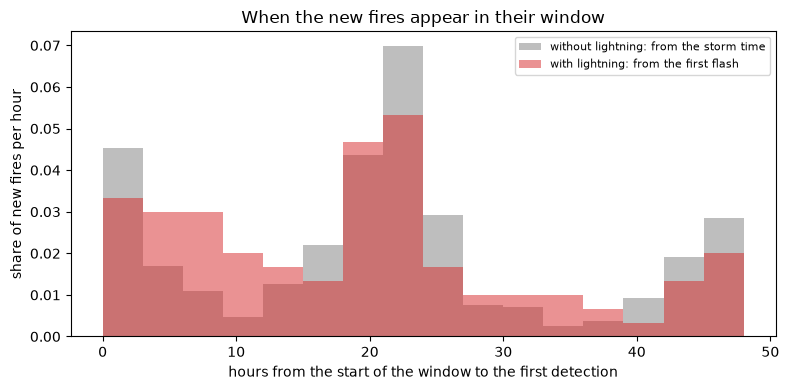

In [27]:
new_fires = table[table.fire_new == 1]
hours = (new_fires.fire_first - new_fires.label_start) / 3600
lit = new_fires.exposed == 1

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, LABEL_HOURS + 3, 3)
ax.hist(hours[~lit], bins=bins, density=True, alpha=0.5, color="tab:grey", label="without lightning: from the storm time")
ax.hist(hours[lit], bins=bins, density=True, alpha=0.5, color="tab:red", label="with lightning: from the first flash")
ax.set_xlabel("hours from the start of the window to the first detection")
ax.set_ylabel("share of new fires per hour")
ax.set_title("When the new fires appear in their window")
ax.legend(fontsize=8)
plt.tight_layout()
for name, h in {"with lightning": hours[lit], "without lightning": hours[~lit]}.items():
    print(f"{name}: {len(h)} fires, median {h.median():.1f} h, first 12 h {(h < 12).mean():.0%}, first 24 h {(h < 24).mean():.0%}")

Each bar shows the share of new fires first seen in a 3 hour step of the 48 hour window, counted from the first flash in cells with lightning (red) and from the storm time in cells without it (grey); darker red is where the two overlap. Both groups peak the same afternoon and the next one, around 24 hours later, because windows start in the afternoon and most fires are seen then. Between 3 and 12 hours, during the first night, the red bars stand above the grey ones: fires in cells with lightning show up sooner, as expected if a flash lit them, although with only 100 such fires the shape is noisy.

### Two checks of the design

**More lightning, more fires?** If lightning starts fires, cells that get many flashes should burn more
often than cells that get a few. The left panel shows the relative risk for four classes of flashes per
cell, each compared with the cells without lightning. A relative risk that grows with the number of
flashes is one of the strongest signs of a real effect that an observational study can give.

**No lightning, no effect?** A sound design should find nothing where there is nothing. The lightning
maps are shuffled at random between storm days 200 times, so the flashes no longer fall where the fires
are counted, and the relative risk is recomputed each time. The right panel shows those values: they
should sit around 1. The share of shuffles that reach the real value is a permutation p value for RQ1.

,cells with lightning,fires with lightning,relative risk,2.5 %,97.5 %
flashes in the cell,,,,,
1-5,5435,27,1.25,0.57,2.06
6-20,3671,32,1.51,0.79,4.20
21-100,3643,23,2.35,1.21,7.13
>100,1826,18,0.98,0.24,4.86


lightning shuffled between days: median 0.97, 95 % of the shuffles between 0.67 and 1.44; permutation p value: 0.045


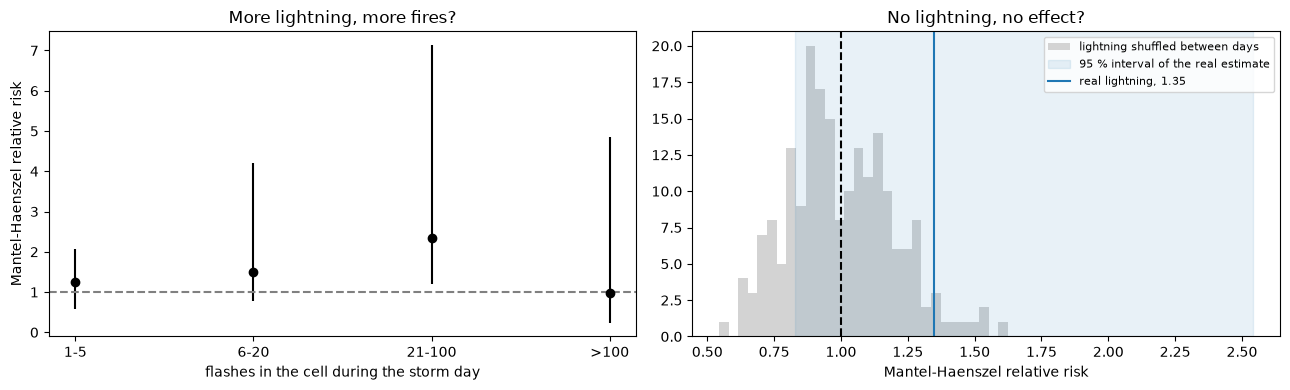

In [28]:
# More lightning, more fires? The relative risk for each class of flashes per cell
dose = pd.cut(table.lfl_flash_count, DOSE_BINS, labels=DOSE_LABELS)
rows = []
for label in DOSE_LABELS:
    t = table[(table.exposed == 0) | (dose == label)]
    ci = np.nanpercentile(episode_bootstrap(t, mantel_haenszel_rr, N_BOOT), [2.5, 97.5])
    rows.append({"flashes in the cell": label, "cells with lightning": int((dose == label).sum()),
                 "fires with lightning": int(table.fire_new[dose == label].sum()),
                 "relative risk": mantel_haenszel_rr(t), "2.5 %": ci[0], "97.5 %": ci[1]})
dose_rr = pd.DataFrame(rows).set_index("flashes in the cell")
display(dose_rr.round(2))

# No lightning, no effect? Lightning maps shuffled between storm days
maps = cube.exposed.values
e = pd.Index(cube.episode.values).get_indexer(table.episode)
yi, xi = pd.Index(cube.y.values).get_indexer(table.y), pd.Index(cube.x.values).get_indexer(table.x)
rng = np.random.default_rng(SEED)
null = np.array([mantel_haenszel_rr(table.assign(exposed=maps[rng.permutation(len(maps))[e], yi, xi].astype(float)))
                 for _ in range(N_PERM)])
p_value = (1 + np.sum(null >= rr)) / (1 + N_PERM)
print(f"lightning shuffled between days: median {np.nanmedian(null):.2f}, 95 % of the shuffles between "
      f"{np.nanpercentile(null, 2.5):.2f} and {np.nanpercentile(null, 97.5):.2f}; permutation p value: {p_value:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_intervals(ax1, dose_rr["relative risk"], dose_rr["2.5 %"], dose_rr["97.5 %"], dose_rr.index)
ax1.set_xlabel("flashes in the cell during the storm day")
ax1.set_ylabel("Mantel-Haenszel relative risk")
ax1.set_title("More lightning, more fires?")
ax2.hist(null[np.isfinite(null)], bins=30, color="lightgrey", label="lightning shuffled between days")
ax2.axvspan(low, high, color="tab:blue", alpha=0.1, label="95 % interval of the real estimate")
ax2.axvline(rr, color="tab:blue", label=f"real lightning, {rr:.2f}")
ax2.axvline(1, color="black", ls="--")
ax2.set_xlabel("Mantel-Haenszel relative risk")
ax2.set_title("No lightning, no effect?")
ax2.legend(fontsize=8)
plt.tight_layout()

### Answer to RQ1

**Probably yes, but one season is not enough to be sure.** Cells hit by lightning had more new fires than
the same cells on days with similar rain and no lightning, but the 95 % interval still includes 1, so H0
cannot be rejected.

**Why the answer stays open.** Lightning lights only a small share of the fires, and the label counts new
fires of every cause. In one season that leaves about a hundred fires in cells with lightning, and the
effect of the flashes is mixed with many fires that would have happened anyway.

**Why it is probably real.** The checks point the same way. When the lightning is shuffled between days,
the relative risk falls back to about 1 and only rarely reaches the real value. The fires in cells with
lightning appear sooner after the flash, which is what an ignition by lightning looks like. And more
flashes bring more fires, except in the cells with the most flashes, possibly because the strongest
storms also bring the most rain; with so few fires that last class cannot be read.

**Fires shared by two days.** How fires that fall inside the windows of two storm days are counted
matters. Giving them to the last storm with lightning raises the estimate. Leaving out the ones shared by
a day with and a day without lightning drops it below 1, but that rule removes about half of the fires in
cells with lightning, because lightning often strikes the same area on consecutive days. The main rule,
the most recent storm, can only err against lightning, so the estimate is, if anything, on the low side.

## RQ2: does dry weather make lightning more dangerous?

**The idea: dry thunderstorms.** Lightning is most likely to start a fire when it strikes
without rain, in what is known as a dry thunderstorm (Rorig and Ferguson, 1999). The difference
between a dry and a wet storm is decided before the storm begins, by how much water the air holds.

```
            DRY STORM                                WET STORM

   dry air before the storm               moist air before the storm
   (little precipitable water)            (much precipitable water)

        .------------------.                   .------------------.
       (    storm cloud     )                 (    storm cloud     )
        '------------------'                   '------------------'
            \     :  :  :                          \     | | | |
            /     rain dries up                    /     | | | |
            \     on the way down                  \     | | | |
   ~~~~~~~~~/~~~~~~~~~~~~~~~~~~~~         ~~~~~~~~~/~~~~~|~|~|~|~~~~~~
      lightning hits dry vegetation          lightning hits wet vegetation
      nothing puts the spark out             the rain puts the spark out

      a new fire is MORE likely              a new fire is LESS likely
```

In the Mediterranean, the storms that start fires tend to have a high cloud base, less water in the
air than usual and little rain (Pérez-Invernón et al., 2021). The GII measures that water in the air,
and how unstable the air is, in the hours before the storm. Rorig and Ferguson (1999) told dry from
wet storm days using the temperature difference between 850 and 500 hPa, the same difference the
K-index is built on.

If this idea holds, cells hit by lightning should burn more often when the air held less water, when
less rain fell and when the vegetation was drier. The rain itself is measured by H61B, but only as a
daily total, which cannot say whether it fell before, with or after the lightning. The GII fills part
of that gap by describing what kind of storm it was.

**How RQ2 tests it.** If dry storms are the ones that start fires, the excess risk of RQ1 should be
larger in dry conditions than in wet ones. The cell below splits the sample into three equal parts
(thirds) by the Fire Weather Index, which describes how dry the fuel is, and into thirds by the
precipitable water before the storm, which describes how much water the air held. It then computes the
relative risk of RQ1 inside each third. The ratio between the driest and the wettest third, with its
bootstrap interval, says how much dry weather changes the effect. The precipitable water only exists
under clear sky, so its thirds use the cells where it is available.

range  fires with lightning  relative risk  \
modifier           third                                                        
Fire Weather Index low       0.0 to 30.5                    57           1.48   
                   middle   30.5 to 46.5                    26           3.08   
                   high    46.5 to 112.5                    17           1.32   
precipitable water low       5.7 to 19.9                     5           1.25   
                   middle   19.9 to 25.8                    35           1.66   
                   high     25.8 to 53.4                    47           1.30   

                           2.5 %  97.5 %  
modifier           third                  
Fire Weather Index low      0.64    3.61  
                   middle   0.76   17.67  
                   high     0.47    3.77  
precipitable water low      0.00    5.01  
                   middle   0.38   11.80  
                   high     0.61    4.06

Fire Weather Index: RR of the driest third / RR of the wettest third = 0.90, 95 % interval 0.28 to 2.87
precipitable water: RR of the driest third / RR of the wettest third = 0.97, 95 % interval 0.00 to 4.17


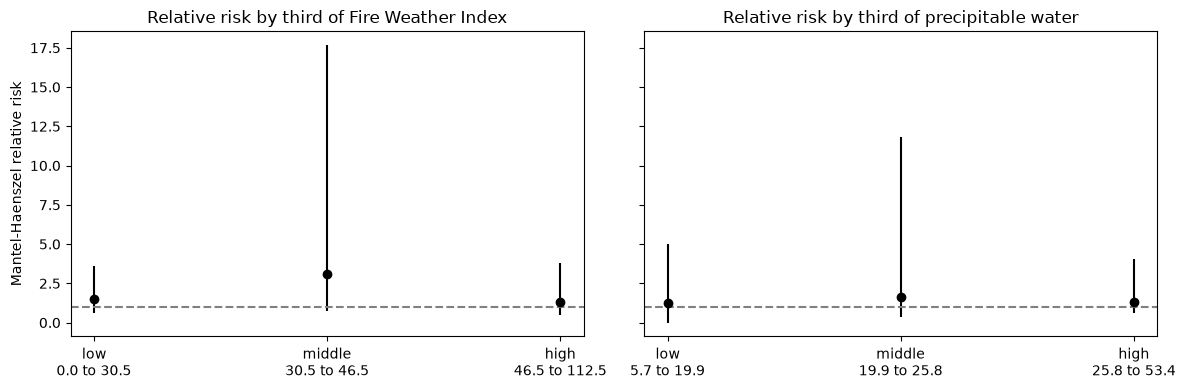

In [29]:
# The relative risk of RQ1 in each third of fuel dryness and of precipitable water
MODIFIERS = {"frm_fwi": ("Fire Weather Index", "high"), "gii_prec_water_total": ("precipitable water", "low")}
THIRDS = ["low", "middle", "high"]

rows, ratios = [], {}
for var, (label, dry) in MODIFIERS.items():
    t = table.dropna(subset=[var])
    t = t.assign(third=pd.qcut(t[var], 3, labels=THIRDS))
    by_third = lambda df: np.array([mantel_haenszel_rr(df[df.third == k]) for k in THIRDS])
    estimate, boot_thirds = by_third(t), episode_bootstrap(t, by_third, N_BOOT)
    ci = np.nanpercentile(boot_thirds, [2.5, 97.5], axis=0)
    for i, k in enumerate(THIRDS):
        rows.append({"modifier": label, "third": k, "range": f"{t[var][t.third == k].min():.1f} to {t[var][t.third == k].max():.1f}",
                     "fires with lightning": int((t.fire_new * t.exposed)[t.third == k].sum()),
                     "relative risk": estimate[i], "2.5 %": ci[0, i], "97.5 %": ci[1, i]})
    wet = "low" if dry == "high" else "high"
    i_dry, i_wet = THIRDS.index(dry), THIRDS.index(wet)
    with np.errstate(divide="ignore", invalid="ignore"):   # a third without fires gives no ratio
        ratios[label] = (estimate[i_dry] / estimate[i_wet], *np.nanpercentile(boot_thirds[:, i_dry] / boot_thirds[:, i_wet], [2.5, 97.5]))
modification = pd.DataFrame(rows).set_index(["modifier", "third"])
display(modification.round(2))
for label, (r, lo, hi) in ratios.items():
    print(f"{label}: RR of the driest third / RR of the wettest third = {r:.2f}, 95 % interval {lo:.2f} to {hi:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (label, _) in zip(axes, MODIFIERS.values()):
    m = modification.loc[label]
    plot_intervals(ax, m["relative risk"], m["2.5 %"], m["97.5 %"], [f"{k}\n{r}" for k, r in zip(THIRDS, m["range"])])
    ax.set_title(f"Relative risk by third of {label}")
axes[0].set_ylabel("Mantel-Haenszel relative risk")
plt.tight_layout()

### Can a model tell which flashes start a fire?

Two models look at the cells hit by lightning and try to tell the ones that burned from the ones that
did not. The outcome is a new fire in the window, of any cause. Ten features describe each cell: the
rain of the day; the three fuel moisture codes (`frm_ffmc`, `frm_dmc`, `frm_dc`), without the Fire
Weather Index, which is built from them; the number of flashes, on a logarithmic scale, and their mean
duration; the tree cover; the day of the season and the north to south position of the cell, which take
care of seasonal and regional trends; and `cell_base_rate`, the new fire rate of the same cell on days
without lightning, which carries the background risk of the place. The GII is left out of the models,
because it only exists under clear sky and would remove many cells.

The main model is a **logistic regression** on standardised features, fitted without penalty so that
its effects are not shrunk. **XGBoost**, a gradient boosted tree model that can capture non linear
effects, is the contrast. Both are trained on the data as they are, without class weights, so their
outputs can be read as probabilities. Each model is trained on 36 storm days and tested on the one left
out, 37 times, so a day is never used for training and testing at once.

Two scores summarise the predictions. The **AUC-PR** measures how well a model ranks the cells that
burned above the others; a model without skill scores the prevalence, the share of cells with a fire.
The **Brier score** is the mean squared error of the predicted probabilities; lower is better. Accuracy
is not used: with fewer than one cell in a hundred burning, a model that always says "no fire" is almost
always right and has learned nothing.

Finally, the logistic regression is fitted on all the storm days to estimate its odds ratios, with 95 %
intervals from the same cluster bootstrap. An odds ratio above 1 means the chance of a new fire rises
with the feature, below 1 that it falls, and an interval that crosses 1 means the data cannot tell the
direction. The three fuel codes describe the same system, so they share their effect and widen each
other's intervals.

cells hit by lightning: 14575 | with every feature: 14575 | new fires among them: 100


,AUC-PR,Brier
logistic,0.0077,0.0068
xgboost,0.0082,0.0069
no skill (prevalence),0.0069,0.0068


,odds ratio,2.5 %,97.5 %
h61_precip,1.074,0.675,1.401
frm_ffmc,1.171,0.969,1.494
frm_dmc,1.124,0.731,1.548
frm_dc,0.761,0.489,1.140
lfl_flash_count,1.149,0.855,1.463
lfl_duration_mean,1.064,0.838,1.230
lc_trees,1.130,0.908,1.392
season_day,1.251,1.027,1.563
y,0.963,0.682,1.354
cell_base_rate,1.197,1.010,1.346


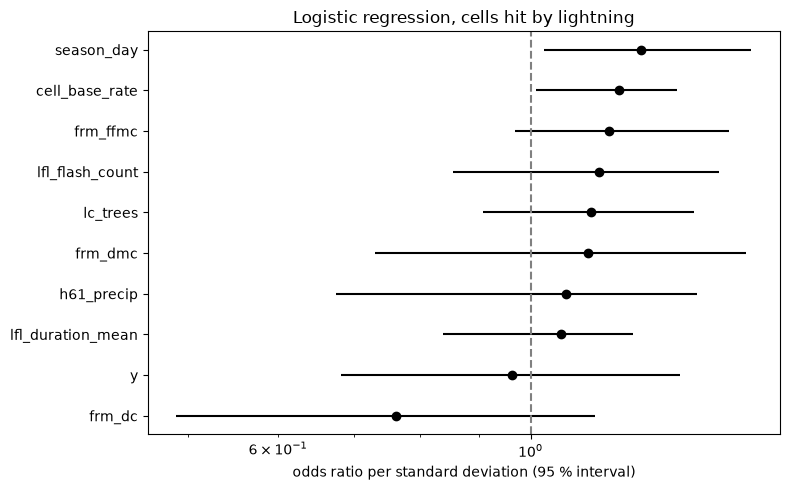

In [30]:
hit = table[table.exposed == 1].copy()
hit["cell_base_rate"] = hit.cell.map(table[table.exposed == 0].groupby("cell").fire_new.mean())
hit["lfl_flash_count"] = np.log1p(hit.lfl_flash_count)
complete = hit[FEATURES_RQ2].notna().all(axis=1)
print(f"cells hit by lightning: {len(hit)} | with every feature: {int(complete.sum())} | "
      f"new fires among them: {int(hit.fire_new[complete].sum())}")

hit = hit[complete]
X_rq2, y_rq2, groups_rq2 = hit[FEATURES_RQ2], hit.fire_new.astype(int), hit.episode

def logistic():
    return make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=1000))

def boosted():
    return XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                         random_state=SEED)

oof = pd.DataFrame(index=hit.index, columns=["logistic", "xgboost"], dtype=float)
for train, test in LeaveOneGroupOut().split(X_rq2, y_rq2, groups_rq2):
    X_train, y_train = X_rq2.iloc[train], y_rq2.iloc[train]
    oof.iloc[test, 0] = logistic().fit(X_train, y_train).predict_proba(X_rq2.iloc[test])[:, 1]
    oof.iloc[test, 1] = boosted().fit(X_train, y_train).predict_proba(X_rq2.iloc[test])[:, 1]

prevalence = y_rq2.mean()
scores = pd.DataFrame({m: {"AUC-PR": average_precision_score(y_rq2, p), "Brier": brier_score_loss(y_rq2, p)}
                       for m, p in oof.items()}).T
scores.loc["no skill (prevalence)"] = [prevalence, prevalence * (1 - prevalence)]
display(scores.round(4))

# The effect of each condition, from the logistic regression fitted on all the storm days
coef_of = lambda df: logistic().fit(df[FEATURES_RQ2], df.fire_new.astype(int))[-1].coef_[0]
coef = coef_of(hit)
ci_low, ci_high = np.nanpercentile(episode_bootstrap(hit, coef_of, N_BOOT), [2.5, 97.5], axis=0)
odds = pd.DataFrame({"odds ratio": np.exp(coef), "2.5 %": np.exp(ci_low), "97.5 %": np.exp(ci_high)}, index=FEATURES_RQ2)
display(odds.round(3))

o = odds.sort_values("odds ratio")
fig, ax = plt.subplots(figsize=(8, 5))
plot_intervals(ax, o["odds ratio"], o["2.5 %"], o["97.5 %"], o.index, horizontal=True)
ax.set_xscale("log")
ax.set_xlabel("odds ratio per standard deviation (95 % interval)")
ax.set_title("Logistic regression, cells hit by lightning")
plt.tight_layout()

### Answer to RQ2

**Not in a way this season can show.** Split into dry and wet thirds, the sample keeps only a handful to a
few dozen fires with lightning in each third. The relative risks of the thirds overlap, and the ratio
between the driest and the wettest third stays close to 1 with very wide intervals. The dry thunderstorm
idea is not contradicted; one season simply does not hold enough lightning fires to test it.

**What the models add.** Neither model does clearly better than a model without skill, so the conditions
of the day do not tell the cells that burned from the others. The only two features with a clear effect
are the day of the season and the background fire rate of the cell. After lightning, a new fire is more
likely late in the summer and in places that burn often anyway; the properties of the storm itself make
no visible difference.

## Limitations

The results hold within the limits of the data, gathered here in one place.

| Limitation | What it does to the results |
|---|---|
| Parallax corrected with one fixed height | Flashes from clouds much lower or higher than 10 km keep part of their shift, so a few land in a neighbouring cell. This pushes the relative risk towards 1 |
| All lightning, not only ground strikes | Only flashes that reach the ground can light a fire, but the Lightning Imager also counts those inside the cloud. Exposure is broader than real contact with the ground |
| Fires of any cause | The label counts every new fire, whatever lit it. Lightning starts a small share of the fires, so its effect is measured on a small part of them |
| Daily satellite rain | H61B is a daily total at about 3 km. It cannot tell whether the rain fell before or after a flash |
| Clear sky air | The instability indices only exist under clear sky, and they are read before the storm over the whole study area, not before the first flash in each cell |
| Fire detection limit | The FCI sees a fire only above a minimum power and not under clouds. Small or smouldering fires are missed, and the time to detection is an upper bound of the holdover |
| Fixed sources from the same season | The rules that remove industrial sources are computed on the season they clean, with reasoned thresholds, and removing eight neighbours can remove a real fire next to a source |
| Fuel is a forecast | The Fire Risk Map is a 24 hour forecast and carries the error of the forecast weather |
| Land cover of 2023 | Three years before the season studied |
| One season | All results come from 2026, which limits the number of fires and widens every interval |

## Conclusions

This notebook took six products from four providers to two answers, and along the way it showed four
things about working with DEFAIR. **The framework can be extended.** Three products without a reader
were brought in with three small plugins, registered through a standard entry point and used exactly
like the official readers. **Very different sources end on one grid.** Gridded and point products,
geostationary and projected, become layers of the same cells through the same read, crop, reproject and
align steps. **The cube is the handover.** One `open_zarr` call is the whole link between the data
pipeline and the analysis, and the same cube serves both a stratified statistical comparison and machine learning models.
**An AI ready cube supports honest statistics.** Because every cell carries its label, its window, its
identity, its rain, its visibility and its storm day, each cell can be compared with itself, the design
can be checked against shuffled lightning, the models can be tested without mixing days, cells the
satellite could not see stay out of the sample, and each fire is counted once.

**What the data say.** New fires were more frequent in cells hit by lightning than in the same cells
without it, and the checks of the design support that this is not chance, but one season leaves the
result short of statistical proof (RQ1). Dry fuel and dry air did not change the effect in a way the
data can show, and the best signs of a fire after lightning were the time of the summer and the place,
not the storm (RQ2).

**Why the ignition questions stay open.** Lightning starts about 15 % of the forest fires of the
Mediterranean Basin ([Soler et al., 2021](https://doi.org/10.1071/WF21076)), and the label counts every
new fire, whatever its cause. The effect of lightning is therefore measured on a small part of the
fires. More seasons, which the same pipeline can process, or records of fire causes would sharpen it.

**Association, not causation.** The results describe how often new fires followed lightning during one
season, not the cause of any single fire. The limits of the data are listed in the table above.

## Resources and references

**Scientific literature**

Bližňák, V., & Sokol, Z. (2026). First validation of the Lightning Imager aboard Meteosat Third Generation satellite with Earth Networks Total Lightning Network. *International Journal of Applied Earth Observation and Geoinformation*, 147, 105205. [https://doi.org/10.1016/j.jag.2026.105205](https://doi.org/10.1016/j.jag.2026.105205)

DaCamara, C. C., Calado, T. J., Ermida, S. L., Trigo, I. F., Amraoui, M., & Turkman, K. F. (2014). Calibration of the Fire Weather Index over Mediterranean Europe based on fire activity retrieved from MSG satellite imagery. *International Journal of Wildland Fire*, 23(7), 945 to 958. [https://doi.org/10.1071/WF13157](https://doi.org/10.1071/WF13157)

Enno, S.-E., Viticchié, B., Navia, D., & Grandell, J. (2026). First year of Meteosat Third Generation Lightning Imager observations. *EGUsphere* preprint, under review for *Atmospheric Measurement Techniques*. [https://doi.org/10.5194/egusphere-2026-3386](https://doi.org/10.5194/egusphere-2026-3386)

Mantel, N., & Haenszel, W. (1959). Statistical aspects of the analysis of data from retrospective studies of disease. *Journal of the National Cancer Institute*, 22(4), 719 to 748. [https://doi.org/10.1093/jnci/22.4.719](https://doi.org/10.1093/jnci/22.4.719)

Moris, J. V., Conedera, M., Nisi, L., Bernardi, M., Cesti, G., & Pezzatti, G. B. (2020). Lightning-caused fires in the Alps: Identifying the igniting strokes. *Agricultural and Forest Meteorology*, 290, 107990. [https://doi.org/10.1016/j.agrformet.2020.107990](https://doi.org/10.1016/j.agrformet.2020.107990)

Moris, J. V., Álvarez-Álvarez, P., Conedera, M., et al. (2023). A global database on holdover time of lightning-ignited wildfires. *Earth System Science Data*, 15, 1151 to 1163. [https://doi.org/10.5194/essd-15-1151-2023](https://doi.org/10.5194/essd-15-1151-2023)

Pérez-Invernón, F. J., Huntrieser, H., Soler, S., Gordillo-Vázquez, F. J., Pineda, N., Navarro-González, J., Reglero, V., Montanyà, J., van der Velde, O., & Koutsias, N. (2021). Lightning-ignited wildfires and long continuing current lightning in the Mediterranean Basin: preferential meteorological conditions. *Atmospheric Chemistry and Physics*, 21, 17529 to 17557. [https://doi.org/10.5194/acp-21-17529-2021](https://doi.org/10.5194/acp-21-17529-2021)

Pineda, N., & Rigo, T. (2017). The rainfall factor in lightning-ignited wildfires in Catalonia. *Agricultural and Forest Meteorology*, 239, 249 to 263. [https://doi.org/10.1016/j.agrformet.2017.03.016](https://doi.org/10.1016/j.agrformet.2017.03.016)

Rodrigues, M., Jiménez-Ruano, A., Gelabert, P. J., Resco de Dios, V., Torres, L., Ribalaygua, J., & Vega-García, C. (2023). Modelling the daily probability of lightning-caused ignition in the Iberian Peninsula. *International Journal of Wildland Fire*, 32(3), 351 to 362. [https://doi.org/10.1071/WF22123](https://doi.org/10.1071/WF22123)

Rorig, M. L., & Ferguson, S. A. (1999). Characteristics of lightning and wildland fire ignition in the Pacific Northwest. *Journal of Applied Meteorology*, 38(11), 1565 to 1575. [https://doi.org/10.1175/1520-0450(1999)038<1565:COLAWF>2.0.CO;2](https://doi.org/10.1175/1520-0450(1999)038<1565:COLAWF>2.0.CO;2)

Soler, A., Pineda, N., San Segundo, H., Bech, J., & Montanyà, J. (2021). Characterisation of thunderstorms that caused lightning-ignited wildfires. *International Journal of Wildland Fire*, 30(12), 954 to 970. [https://doi.org/10.1071/WF21076](https://doi.org/10.1071/WF21076)

Van Wagner, C. E. (1987). *Development and structure of the Canadian Forest Fire Weather Index System*. Canadian Forestry Service, Forestry Technical Report 35, Ottawa. [https://cfs.nrcan.gc.ca/pubwarehouse/pdfs/19927.pdf](https://cfs.nrcan.gc.ca/pubwarehouse/pdfs/19927.pdf)

Vecín-Arias, D., Castedo-Dorado, F., Ordóñez, C., & Rodríguez-Pérez, J. R. (2016). Biophysical and lightning characteristics drive lightning-induced fire occurrence in the central plateau of the Iberian Peninsula. *Agricultural and Forest Meteorology*, 225, 36 to 47. [https://doi.org/10.1016/j.agrformet.2016.05.003](https://doi.org/10.1016/j.agrformet.2016.05.003)

**Product documentation**

LSA SAF, *Product User Manual for Fire Risk Map, version 2 (FRM2)*, product LSA-504.2, SAF/LAND/IDL/PUM_FRM2/1.0, 2020. LSA SAF, *Product User Manual for the MTG FRP-Pixel product*, SAF/LAND/IPMA/PUM_MTFRP/1.0. LSA SAF, *Product Output Format*, SAF/LAND/IPMA/POF/1.2, available in the [LSA SAF documentation repository](https://nextcloud.lsasvcs.ipma.pt/s/CjtrxjMcYBz5wT7?dir=/PUM-Product_User_Manual). EUMETSAT, *MSG Level 1.5 Image Data Format Description*, EUM/MSG/ICD/105, v8, 2017, [user.eumetsat.int](https://user.eumetsat.int/s3/eup-strapi-media/pdf_ten_05105_msg_img_data_e7c8b315e6.pdf). EUMETSAT, *MTG LI Level 2 Format Specification*, [user.eumetsat.int](https://user.eumetsat.int/s3/eup-strapi-media/MTG_LI_Level_2_Format_Specification_12c067c926.pdf). Pytroll, satpy area definitions, area `msg_seviri_fes_3km`, [satpy/etc/areas.yaml](https://github.com/pytroll/satpy/blob/main/satpy/etc/areas.yaml). The EUMETSAT User Portal describes the MTG products in the [MTG FCI L2 GII data guide](https://user.eumetsat.int/resources/user-guides/mtg-fci-l2-gii-data-guide) and the [MTG LI Level 2 data guide](https://user.eumetsat.int/resources/user-guides/mtg-li-level-2-data-guide). The Copernicus Land Monitoring Service documents the land cover in the [CLCplus Backbone 2023 Product User Manual](https://library.land.copernicus.eu/products/CLCplus_Backbone_2023_PUM_v1.pdf).

**Destination Earth DataLake and DEFAIR**

Data discovery and access use the Harmonised Data Access STAC API at [https://hda.data.destination-earth.eu](https://github.com/destination-earth/DestinE-DataLake-Lab/tree/main/HDA), the DataLake S3 object store at [https://s3.central.data.destination-earth.eu](https://s3.central.data.destination-earth.eu) and the DestinE JupyterHub where this notebook runs. The [DestinE DataLake Lab repository](https://github.com/destination-earth/DestinE-DataLake-Lab) collects the official access notebooks this project builds on. This notebook uses DEFAIR 0.4.0rc3.